# Investigation : que se passe-t-il dans l'espace des parametres ?

Notebook complementaire a `imgep_investigation.ipynb`, qui mesurait la diversite dans
l'espace de **comportement** Z (38 descripteurs perceptifs). Celui-ci pose la question un
cran en amont : **dans l'espace des parametres Theta (144 dimensions explorables), les
parametres bougent-ils, et bougent-ils assez ?**

Trois questions, dans l'ordre :

1. La distribution de Theta est-elle deja effondree, ou le probleme est-il uniquement dans
   la cartographie Theta -> Z ?
2. Quels parametres bougent, lesquels restent figes, et le pas de mutation est-il correct
   parametre par parametre ?
3. Reduire le probleme (explorer moins de parametres a la fois) rend-il l'exploration
   guidee productive ?

**Reponses courtes** : (1) oui, effondrement d'un facteur 10 des le niveau Theta ;
(2) aucun des 144 parametres n'atteint le pas du tirage aleatoire, certains a 10% ;
(3) non -- et c'est meme pire, avec un verrouillage total sur le silence.

> Page de synthese des resultats (privee, hebergee sur claude.ai) :
> <https://claude.ai/code/artifact/3f04f0b0-b04e-4254-be71-7a8e5ed9f713>

**Plan**
1. Setup
2. Distribution globale de Theta (baseline / niche-bias / random)
3. Trajectoire des parametres au fil des iterations (heatmap)
4. Pas de mutation, parametre par parametre
5. Reduction du sous-espace : protocole
6. Resultats : le verrouillage sur le silence
7. Le preset gele est-il en cause ? (preset humain median)
8. Conclusion

## 1. Setup

In [2]:
import os, sys, pathlib, json, sqlite3
os.environ['LD_LIBRARY_PATH'] = '/data/anasynth_nonbp/manaconda3/lib:' + os.environ.get('LD_LIBRARY_PATH', '')

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from IPython.display import Image, display

DEXED_ROOT = pathlib.Path.home() / 'projects' / 'spinvae2' / 'adtool' / 'dexed'
os.chdir(DEXED_ROOT)
sys.path.insert(0, str(DEXED_ROOT))
sys.path.insert(0, str(pathlib.Path.home() / 'projects' / 'spinvae2'))

from coverage_diversity import load_z_matrix, vendi_score

# Mirrors DexedParameterMap.FIXED_INDICES -- importing the map itself would drag in the whole
# DawDreamer/adtool system stack for two constants.
N_VST_PARAMS = 155
FIXED_INDICES = {0, 1, 2, 3, 13, 44, 66, 88, 110, 132, 154}
LEARNABLE = [i for i in range(N_VST_PARAMS) if i not in FIXED_INDICES]

conn = sqlite3.connect(str(pathlib.Path.home() / 'projects/spinvae2/synth/dexed_presets.sqlite'))
ALL_PARAM_NAMES = pd.read_sql_query('SELECT * FROM param ORDER BY index_param', conn)['name'].to_list()
conn.close()
LEARNABLE_NAMES = [ALL_PARAM_NAMES[i] for i in LEARNABLE]

print('cwd:', os.getcwd())
print(f'Theta : {len(LEARNABLE)} parametres explorables sur {N_VST_PARAMS}')

cwd: /net/home/u.anasynth/longeot/projects/spinvae2/adtool/dexed
Theta : 144 parametres explorables sur 155


In [3]:
def load_theta(discoveries_dir, cap=None):
    """Charge les valeurs brutes des parametres (Theta), en ordre chronologique."""
    files = sorted(pathlib.Path(discoveries_dir).rglob('discovery.json'))
    if cap is not None:
        files = files[:cap]
    rows = []
    for f in files:
        preset = json.load(f.open())['params']['dynamic_params']['preset']
        rows.append([v for _, v in preset])
    return np.asarray(rows, dtype=float)[:, LEARNABLE]


def drop_nan(M):
    return M[~np.isnan(M).any(axis=1)]


def silence_rate(Z):
    """Part de decouvertes quasi-silencieuses : Z tout-a-zero, le fallback de
    DexedStatistics quand le rendu a une crete < 1e-4 (cf. investigation section 16)."""
    return 100.0 * (np.abs(Z).max(axis=1) < 1e-9).mean()

## 2. Distribution globale de Theta

Toutes les mesures de diversite jusqu'ici portaient sur Z. Question prealable : le nuage de
points est-il deja resserre dans Theta ? Si Theta est aussi etale que celui du random, le
probleme est purement dans la cartographie Theta -> Z. S'il est effondre, la recherche
locale ne quitte jamais une petite region de l'espace des parametres.

Trois jeux compares, n=1000 chacun : baseline (IMGEP standard), niche-bias + algomut (le
seul levier qui ait fonctionne, cf. investigation section 20), et random.

In [4]:
THETA_RUNS = {
    'baseline': 'runs/sweeps/bootstrap/bs100/discoveries',
    'niche k=5+algomut': 'runs/nichebias/k5_algomut/seed0/discoveries',
    'random': 'runs/random/combined/discoveries',
}

theta = {name: drop_nan(load_theta(d, cap=1000)) for name, d in THETA_RUNS.items()}
for name, M in theta.items():
    print(f'{name:20s} {M.shape}')

baseline             (1000, 144)
niche k=5+algomut    (1000, 144)
random               (1000, 144)


In [5]:
print('=== 1. Ecart-type moyen par parametre ===')
for name, M in theta.items():
    sd = M.std(axis=0)
    print(f'  {name:20s} moyenne {sd.mean():.4f} | mediane {np.median(sd):.4f} | min {sd.min():.4f} | max {sd.max():.4f}')

print()
print('=== 2. Parametres quasi figes (std < 0.05) ===')
for name, M in theta.items():
    sd = M.std(axis=0)
    print(f'  {name:20s} {(sd < 0.05).sum():3d} / {len(sd)}')

print()
print('=== 3. Etendue interquartile moyenne (random uniforme theorique ~ 0.50) ===')
for name, M in theta.items():
    iqr = np.percentile(M, 75, axis=0) - np.percentile(M, 25, axis=0)
    print(f'  {name:20s} IQR moyen {iqr.mean():.4f}')

print()
print('=== 4. Rayon du nuage (distance moyenne au centroide) ===')
for name, M in theta.items():
    dist = np.linalg.norm(M - M.mean(axis=0), axis=1)
    print(f'  {name:20s} {dist.mean():.3f} +/- {dist.std():.3f}  (dim={M.shape[1]})')

print()
print('=== 5. Distance entre decouvertes CONSECUTIVES (localite de la mutation) ===')
for name, M in theta.items():
    step = np.linalg.norm(np.diff(M, axis=0), axis=1)
    print(f'  {name:20s} {step.mean():.3f} +/- {step.std():.3f}')

=== 1. Ecart-type moyen par parametre ===
  baseline             moyenne 0.1506 | mediane 0.1419 | min 0.0841 | max 0.4999
  niche k=5+algomut    moyenne 0.2888 | mediane 0.2834 | min 0.1272 | max 0.4997
  random               moyenne 0.3183 | mediane 0.3002 | min 0.2647 | max 0.5000

=== 2. Parametres quasi figes (std < 0.05) ===
  baseline               0 / 144
  niche k=5+algomut      0 / 144
  random                 0 / 144

=== 3. Etendue interquartile moyenne (random uniforme theorique ~ 0.50) ===
  baseline             IQR moyen 0.0540
  niche k=5+algomut    IQR moyen 0.4315
  random               IQR moyen 0.5588

=== 4. Rayon du nuage (distance moyenne au centroide) ===
  baseline             1.515 +/- 1.226  (dim=144)
  niche k=5+algomut    3.592 +/- 0.224  (dim=144)
  random               3.870 +/- 0.123  (dim=144)

=== 5. Distance entre decouvertes CONSECUTIVES (localite de la mutation) ===
  baseline             1.848 +/- 1.235
  niche k=5+algomut    4.803 +/- 1.586
  rand

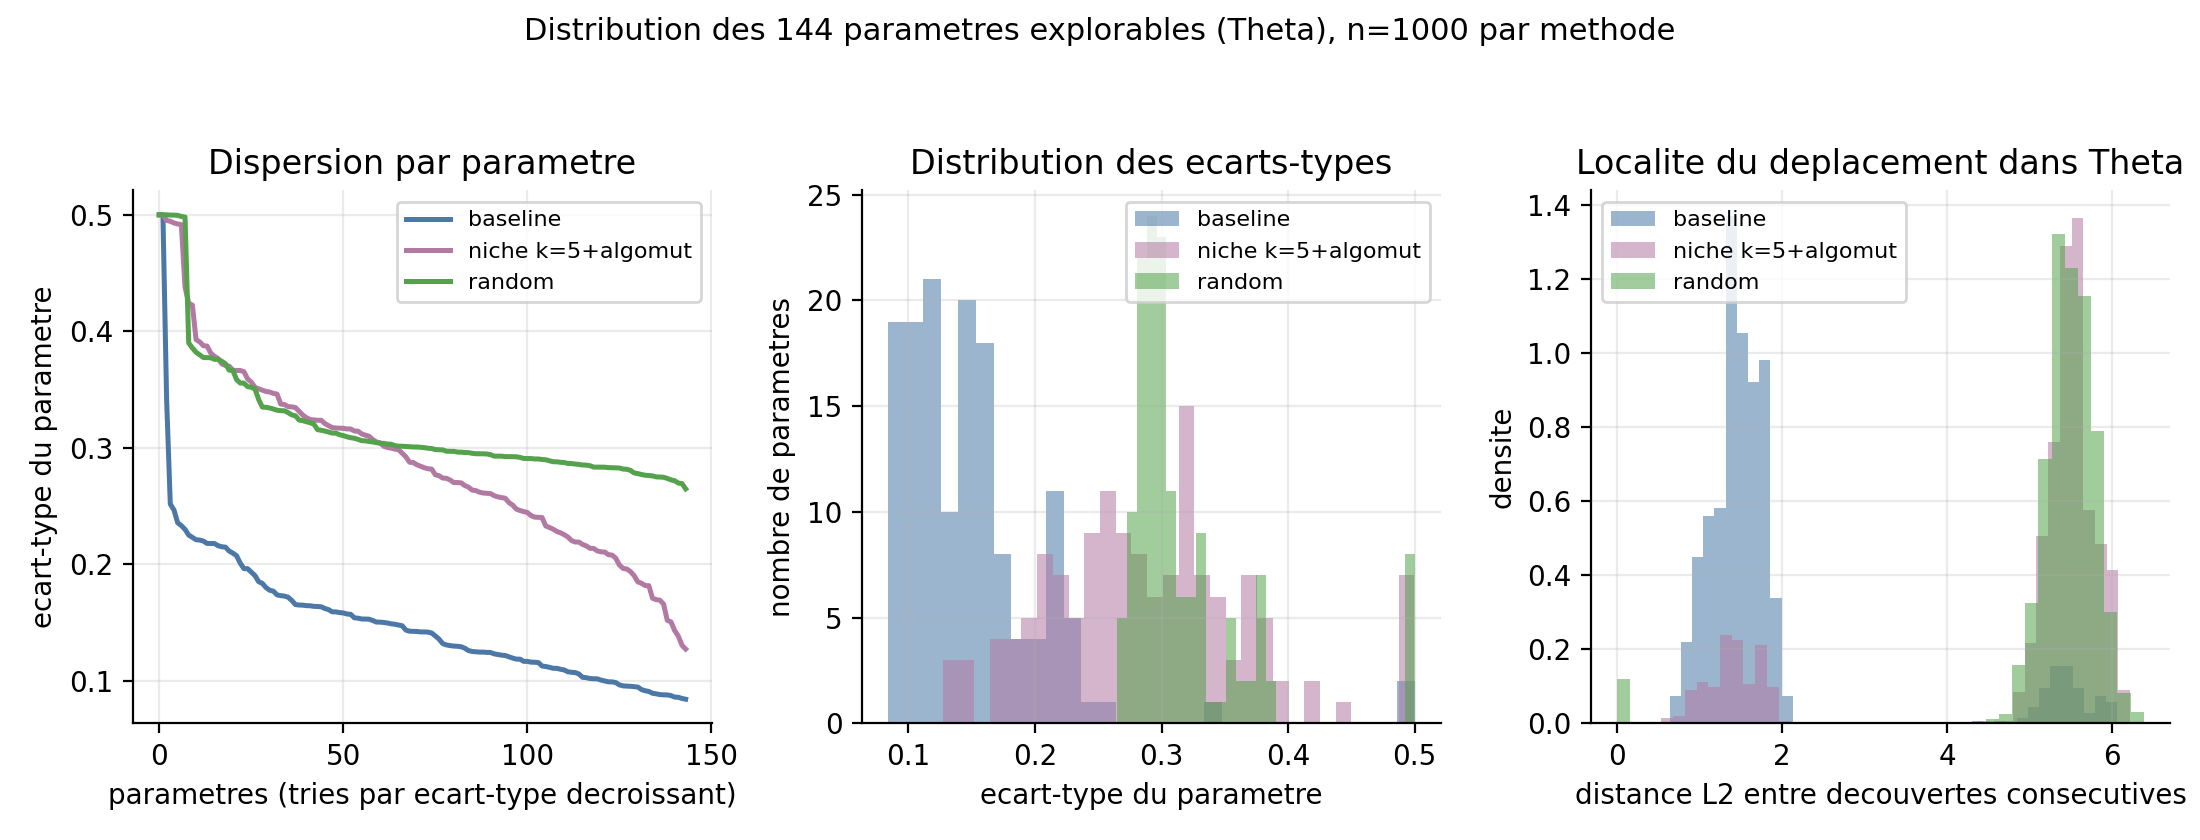

In [6]:
display(Image('figures/theta_distribution.png'))

### Resultat : l'effondrement est deja visible dans Theta, d'un facteur 10

| | IQR moyen | rayon du nuage | pas entre decouvertes |
|---|---|---|---|
| baseline | **0.054** | 1.52 +/- 1.23 | 1.85 |
| niche k=5+algomut | 0.432 | 3.59 +/- 0.22 | 4.80 |
| random | 0.559 | 3.87 +/- 0.12 | 5.39 |

La baseline ne parcourt qu'**un dixieme** de l'etendue que le hasard couvre sur chaque
parametre. Ce n'est pas un parametre bloque en particulier : 0/144 ont un ecart-type
inferieur a 0.05, c'est le nuage entier qui est resserre.

Detail revelateur : la baseline a un ecart-type moyen de 0.15 mais un IQR de 0.054. Cette
combinaison signale des **queues lourdes** -- la masse est concentree dans une region
minuscule, avec quelques echappees lointaines. C'est exactement la signature attendue de
l'attracteur de silence (investigation section 16) plus de rares evasions.

**Le niche-bias restaure presque entierement l'etalement dans Theta** (0.43 contre 0.56 ;
rayon 3.59 contre 3.87). Pourtant, dans Z, il ne recupere que 88% de la couverture et 34%
du Vendi. Il reste donc une seconde perte, distincte, qui se produit dans la cartographie
Theta -> Z.

## 3. Trajectoire des parametres au fil des iterations

Les statistiques agregees ci-dessus disent *combien* ca bouge, pas *quand*. La heatmap
montre chaque parametre (une ligne) au fil des iterations (colonnes), couleur = valeur.
Un parametre qui ne bouge jamais apparait comme une bande horizontale de couleur uniforme.

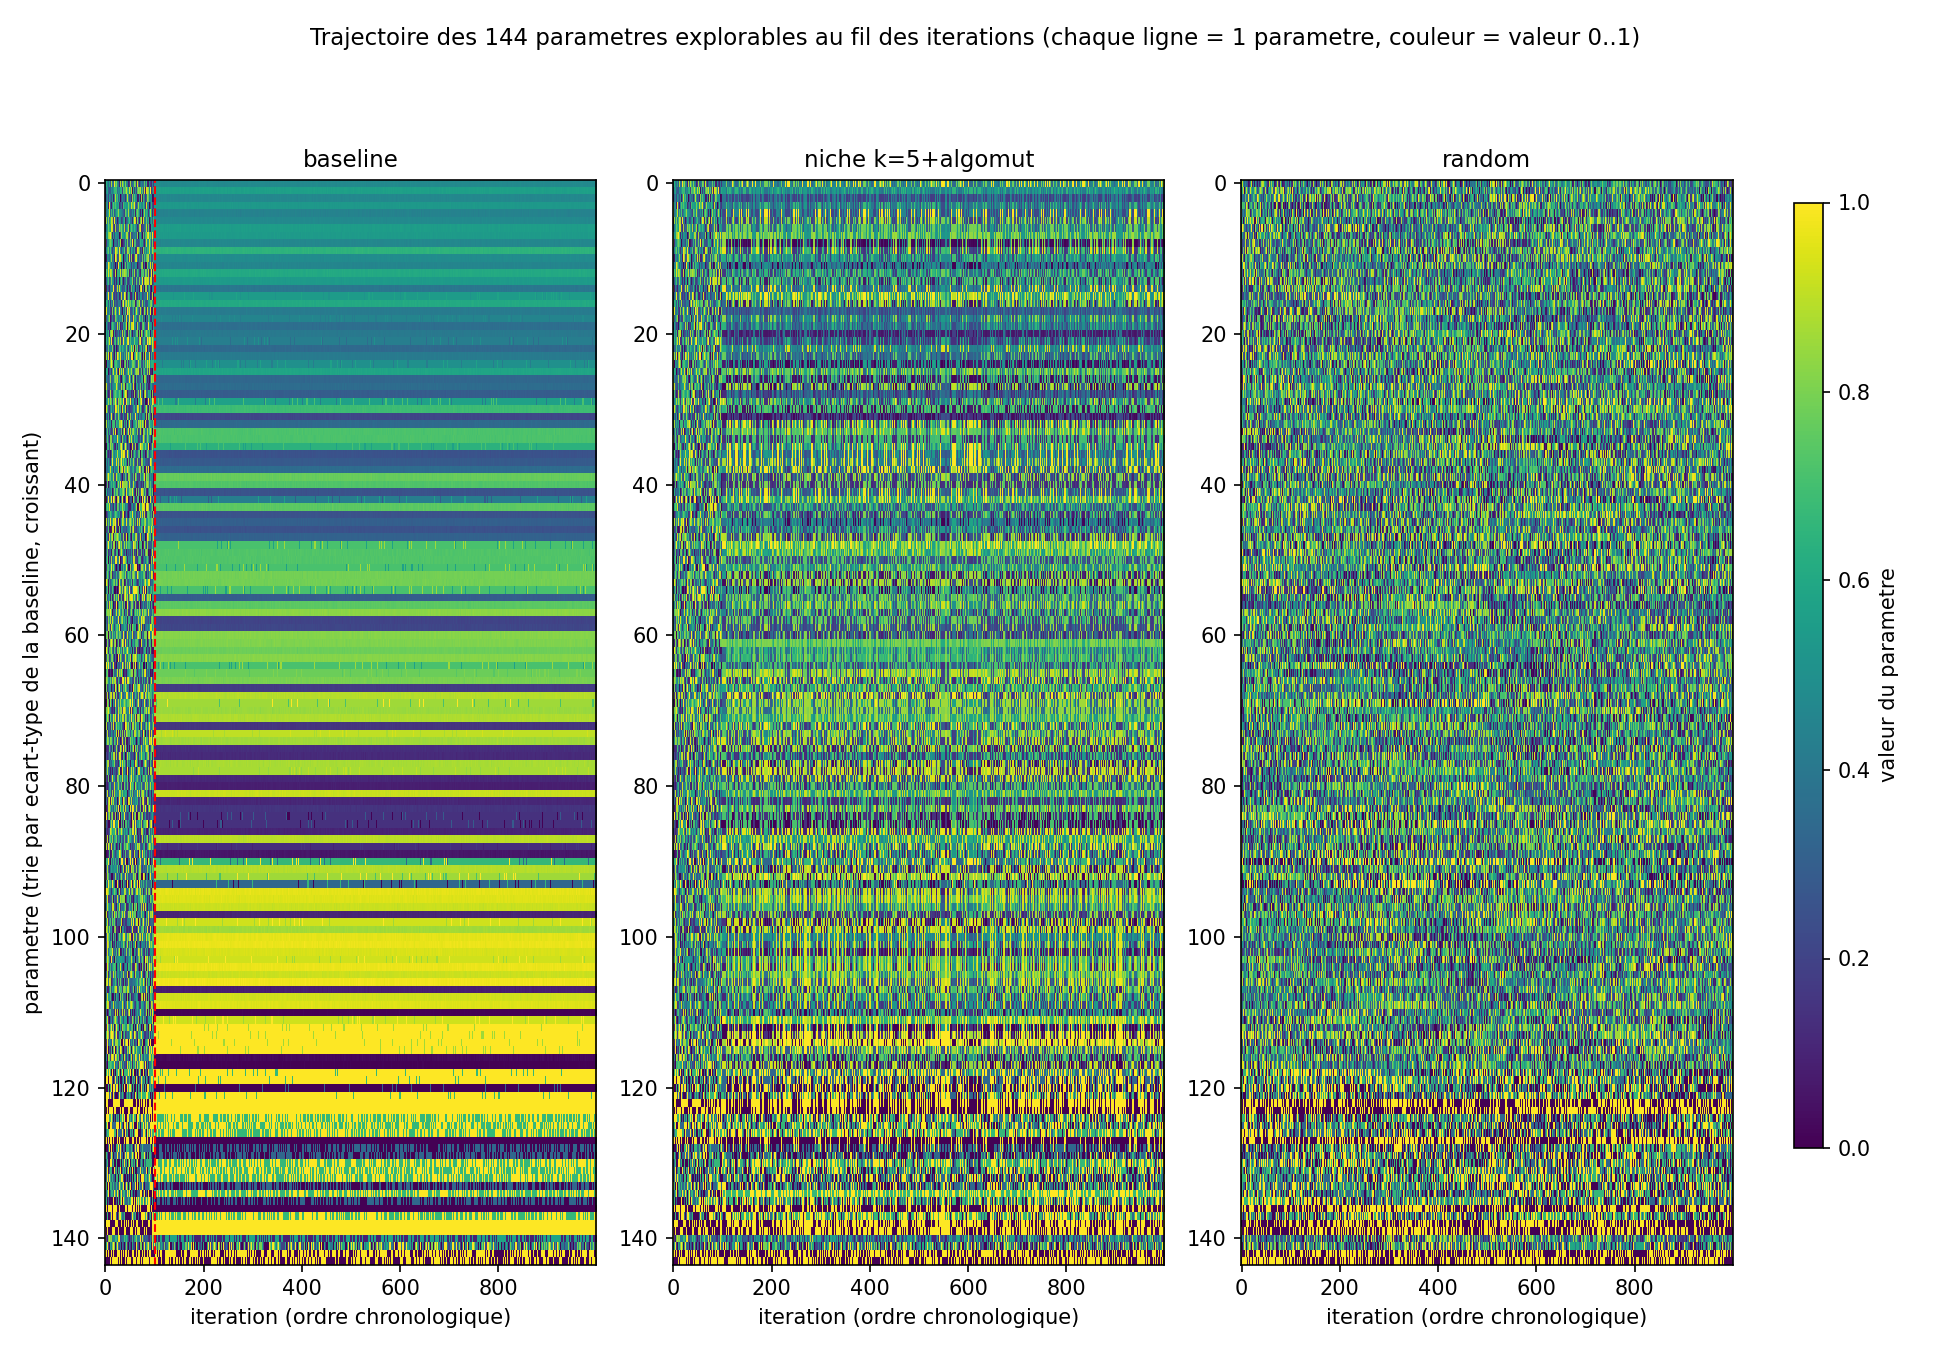

In [7]:
display(Image('figures/theta_heatmap.png'))

### Resultat : des bandes figees, pas seulement un pas trop petit

Sur le panneau baseline, on voit des **bandes horizontales quasi uniformes sur toute la
largeur** : un parametre se fixe quelque part tot dans le run et n'en bouge plus jusqu'a
l'iteration 1000. Ce n'est pas de la lenteur, c'est une **convergence prematuree** -- une
fois qu'un parametre a derive vers une valeur, la mutation locale ne l'en fait plus sortir.

Le panneau niche+algomut a nettement moins de bandes plates, de la texture verticale
partout, plus proche (sans l'egaler) du bruit uniforme du panneau random. Le mecanisme
empeche donc les parametres de se figer -- pas seulement il elargit leur plage.

## 4. Le pas de mutation, parametre par parametre

La distance L2 globale entre decouvertes consecutives (section 2) melange les 144
dimensions. Ici on mesure le deplacement moyen `|delta|` applique a **chaque** parametre
pris isolement, compare au meme pas dans le tirage aleatoire. Un ratio proche de 1 = le
parametre bouge normalement ; proche de 0 = il est quasiment gele malgre `noise_scale=1.0`.

In [8]:
step_baseline = np.abs(np.diff(theta['baseline'], axis=0)).mean(axis=0)
step_random = np.abs(np.diff(theta['random'][:1000], axis=0)).mean(axis=0)
order = np.argsort(step_baseline)

print('=== 10 parametres au pas le plus FAIBLE (baseline) ===')
for i in order[:10]:
    ratio = step_baseline[i] / max(step_random[i], 1e-9)
    print(f'  {LEARNABLE_NAMES[i]:28s} baseline={step_baseline[i]:.4f}  random={step_random[i]:.4f}  ratio={ratio:.2f}')

print()
print('=== 10 parametres au pas le plus FORT (baseline) ===')
for i in order[-10:][::-1]:
    ratio = step_baseline[i] / max(step_random[i], 1e-9)
    print(f'  {LEARNABLE_NAMES[i]:28s} baseline={step_baseline[i]:.4f}  random={step_random[i]:.4f}  ratio={ratio:.2f}')

=== 10 parametres au pas le plus FAIBLE (baseline) ===
  OP5 EG LEVEL 2               baseline=0.0321  random=0.3260  ratio=0.10
  OP3 EG LEVEL 4               baseline=0.0323  random=0.3438  ratio=0.09
  OP5 EG LEVEL 3               baseline=0.0325  random=0.3144  ratio=0.10
  OP2 OUTPUT LEVEL             baseline=0.0345  random=0.3447  ratio=0.10
  OP3 L SCALE DEPTH            baseline=0.0345  random=0.3551  ratio=0.10
  OP3 BREAK POINT              baseline=0.0345  random=0.3297  ratio=0.10
  OP5 EG RATE 1                baseline=0.0346  random=0.3234  ratio=0.11
  OP6 EG LEVEL 2               baseline=0.0348  random=0.3288  ratio=0.11
  OP6 F FINE                   baseline=0.0348  random=0.3360  ratio=0.10
  OP4 F COARSE                 baseline=0.0355  random=0.3492  ratio=0.10

=== 10 parametres au pas le plus FORT (baseline) ===
  LFO KEY SYNC                 baseline=0.5125  random=0.4785  ratio=1.07
  OSC KEY SYNC                 baseline=0.5035  random=0.5055  ratio=1.00
  L

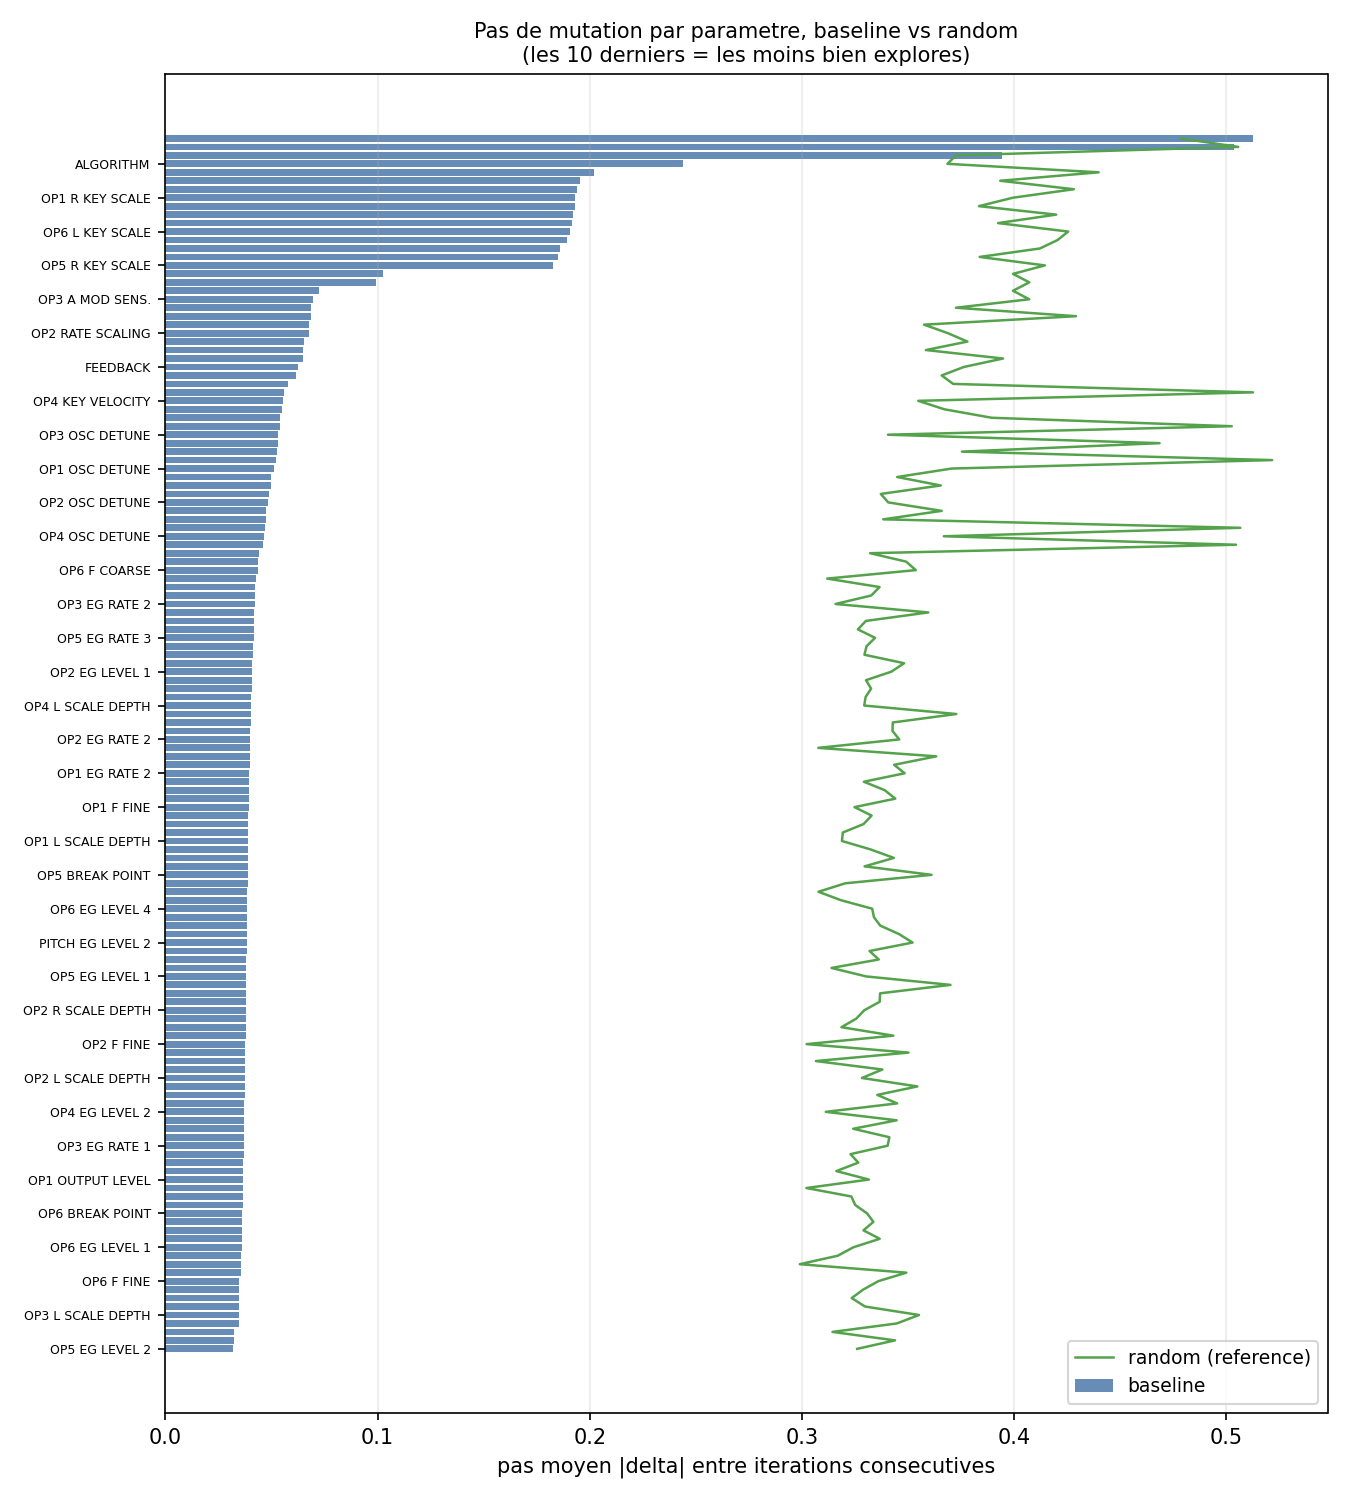

In [9]:
display(Image('figures/theta_step_per_param.png'))

### Resultat : aucun des 144 parametres n'atteint le pas du random

**Les pires** (ratio ~0.09-0.11, soit 10x trop petit) : `OP5 EG LEVEL 2`, `OP3 EG LEVEL 4`,
`OP2 OUTPUT LEVEL`, `OPx BREAK POINT`, `OPx F FINE` -- les parametres de mise en forme fine
et de niveau.

**Les moins pires** (ratio ~0.45-0.66, encore 1.5-2x trop petit) : `ALGORITHM`, `FEEDBACK`,
`OPx KEY SCALE` -- les parametres structurels, qui ont un traitement de mutation special
dans `get_similar_preset()`.

Ce n'est donc pas quelques parametres a la traine : c'est **systemique**.

Ca eclaire aussi pourquoi le sweep `noise_scale` (x0.5 a x4, investigation section 3)
restait plat : le levier scale le bruit *avant* clipping, et si les valeurs derivent pres
des bords [0,1] au fil du run, le clip absorbe l'essentiel du gain. Mais le levier
`reflect_boundary` (section 7.2) avait echoue a corriger ca -- donc le clipping seul
n'explique pas tout. La convergence en bandes de la section 3 suggere plutot une boucle ou
le plus proche voisin du but successif reste dans la meme region, independamment du clipping.

## 5. Reduire le probleme : exploration a sous-espace restreint

Hypothese testee : peut-etre que la mutation locale se perd simplement dans 144 dimensions.
En n'explorant qu'une poignee de parametres FM decisifs, l'exploration guidee devrait
fonctionner -- on pourrait ensuite agrandir le sous-espace progressivement.

`DexedParameterMap.explore_indices` restreint l'exploration a un sous-ensemble ; tous les
autres parametres sont geles sur un preset de base fixe pour tout le run (pas sur des
zeros, qui donneraient un silence quel que soit le sous-espace explore).

Echelle construite depuis la vraie structure Dexed (6 operateurs x 22 parametres,
operateur n a l'index 23+22(n-1), verifie contre `dexed_presets.sqlite`) :

| Niveau | Dim | Contenu |
|---|---|---|
| `L1_core14` | 14 | ALGORITHM, FEEDBACK, + par operateur : OUTPUT LEVEL, F COARSE |
| `L2_tuning26` | 26 | + par operateur : F FINE, OSC DETUNE |
| `L3_env74` | 74 | + par operateur : EG RATE 1-4, EG LEVEL 1-4 |

Le coeur FM d'abord (routage, profondeur de modulation, rapports de frequence), puis
l'accordage fin, puis les enveloppes d'amplitude.

In [10]:
levels = json.load(open('configs/restricted/explore_levels.json'))
for name, idx in levels.items():
    print(f'{name}: {len(idx)} parametres')
    print('   ', ', '.join(ALL_PARAM_NAMES[i] for i in idx[:8]), '...' if len(idx) > 8 else '')

L1_core14: 14 parametres
    ALGORITHM, FEEDBACK, OP1 OUTPUT LEVEL, OP1 F COARSE, OP2 OUTPUT LEVEL, OP2 F COARSE, OP3 OUTPUT LEVEL, OP3 F COARSE ...
L2_tuning26: 26 parametres
    ALGORITHM, FEEDBACK, OP1 OUTPUT LEVEL, OP1 F COARSE, OP1 F FINE, OP1 OSC DETUNE, OP2 OUTPUT LEVEL, OP2 F COARSE ...
L3_env74: 74 parametres
    ALGORITHM, FEEDBACK, OP1 EG RATE 1, OP1 EG RATE 2, OP1 EG RATE 3, OP1 EG RATE 4, OP1 EG LEVEL 1, OP1 EG LEVEL 2 ...


## 6. Resultat : le verrouillage sur le silence

3 seeds par niveau, 1000 iterations, bootstrap=100, meme protocole que la baseline.

In [11]:
RESTRICTED = {
    'baseline (144-D)': lambda s: ('runs/sweeps/bootstrap/bs100/discoveries' if s == 0
                                    else f'runs/sweeps/bootstrap/bs100_seed{s}/discoveries'),
    'L1 core (14-D)': lambda s: f'runs/restricted/L1_core14/seed{s}/discoveries',
    'L2 tuning (26-D)': lambda s: f'runs/restricted/L2_tuning26/seed{s}/discoveries',
    'L3 envelopes (74-D)': lambda s: f'runs/restricted/L3_env74/seed{s}/discoveries',
}
SEEDS = [0, 1, 2]
N_BOOT = 100

restricted_z = {}
for name, fn in RESTRICTED.items():
    restricted_z[name] = [drop_nan(load_z_matrix(fn(s))[:1000]) for s in SEEDS]
    print(f'{name:22s} {[len(M) for M in restricted_z[name]]}')

baseline (144-D)       [1000, 1000, 1000]
L1 core (14-D)         [1000, 1000, 1000]
L2 tuning (26-D)       [1000, 1000, 1000]
L3 envelopes (74-D)    [1000, 1000, 1000]


In [12]:
print('=== Taux de silence : bootstrap vs phase guidee ===')
for name, runs in restricted_z.items():
    boot = [silence_rate(M[:N_BOOT]) for M in runs]
    goal = [silence_rate(M[N_BOOT:]) for M in runs]
    print(f'  {name:22s} bootstrap {np.mean(boot):5.1f}%  ->  guide {np.mean(goal):5.1f}%'
          f'   (par seed : {[round(g,1) for g in goal]})')

=== Taux de silence : bootstrap vs phase guidee ===
  baseline (144-D)       bootstrap  13.7%  ->  guide  70.8%   (par seed : [np.float64(58.1), np.float64(96.1), np.float64(58.1)])
  L1 core (14-D)         bootstrap  14.3%  ->  guide 100.0%   (par seed : [np.float64(100.0), np.float64(100.0), np.float64(100.0)])
  L2 tuning (26-D)       bootstrap  14.7%  ->  guide 100.0%   (par seed : [np.float64(100.0), np.float64(100.0), np.float64(100.0)])
  L3 envelopes (74-D)    bootstrap  14.3%  ->  guide  99.9%   (par seed : [np.float64(100.0), np.float64(99.6), np.float64(100.0)])


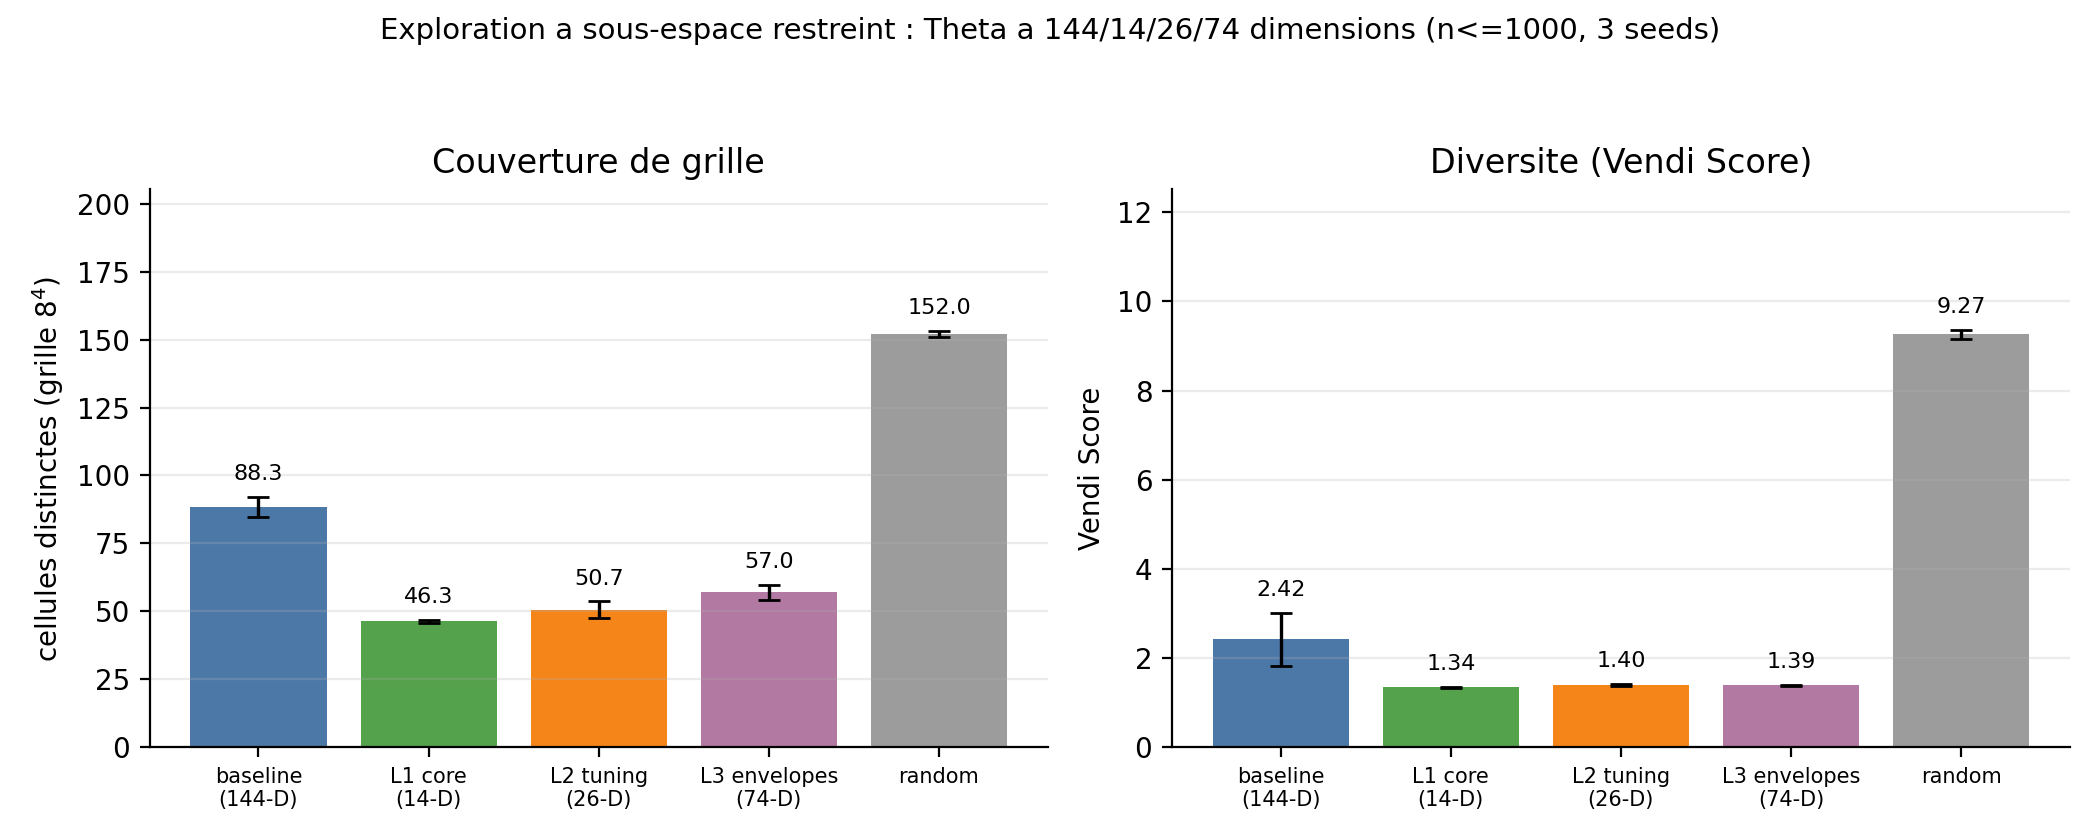

In [13]:
display(Image('figures/restricted_subspace.png'))

### Resultat : capture totale, dans les 9 runs sans exception

| | bootstrap | phase guidee |
|---|---|---|
| L1 core (14-D) | 11-16% | **100.0%** (3/3 seeds) |
| L2 tuning (26-D) | 12-16% | **100.0%** (3/3 seeds) |
| L3 envelopes (74-D) | 13-15% | **99.6-100.0%** (3/3 seeds) |

Le bootstrap reste normal (11-16%, coherent avec les 11.5% du random). Mais des que la
mutation guidee demarre, le taux de silence saute a 100% et y reste 900 iterations --
verrouillage total, jamais une seule evasion.

Vendi et couverture suivent : L1 tombe a 1.34 de Vendi et 46 cellules, contre 2.42 et 88
pour la baseline a 144-D, et 9.27 / 152 pour le random.

**C'est l'inverse de l'hypothese.** Moins de dimensions = **moins de portes de sortie** une
fois piege dans le silence. Dans l'espace complet a 144-D, une mutation locale a 144 chances
de tomber sur une combinaison qui sonne encore ; a 14-D il n'y en a plus que 14, et
apparemment ca ne suffit jamais.

C'est la demonstration la plus propre de H3 (attracteurs degeneres) obtenue dans toute
l'investigation : passer de 144-D a 74-D suffit deja a faire sauter le taux de ~65% a ~100%.

## 7. Le preset gele est-il en cause ?

Objection legitime : les trois niveaux partagent le **meme** preset de base gele (un tirage
aleatoire, `base_preset_seed=0`). Si ce tirage est mauvais -- par exemple s'il neutralise
certains operateurs -- il pourrait expliquer a lui seul le verrouillage, independamment de
la taille du sous-espace.

Test : refaire les 9 runs en gelant les parametres sur un **vrai preset humain** au lieu
d'un tirage synthetique. `base_preset_mode='human_median'` utilise le preset humain le plus
proche (distance L2 sur les 144 dimensions explorables) de la **mediane coordonnee par
coordonnee** de toute la base de 30 145 presets humains : UID 4661, *"STR JB 01"*.
Contrairement a un tirage aleatoire, c'est un son qui fonctionne par construction.

In [14]:
sys.path.insert(0, str(DEXED_ROOT))
from maps.DexedParameterMap import DexedParameterMap

pm_random = DexedParameterMap(system=None, seed=0, explore_indices=levels['L1_core14'])
pm_human = DexedParameterMap(system=None, seed=0, explore_indices=levels['L1_core14'],
                              base_preset_mode='human_median')
base_random, base_human = pm_random._base_preset, pm_human._base_preset
frozen_idx = [i for i in pm_random.learnable_indices if i not in set(levels['L1_core14'])]

# Contre-intuitif : c'est le preset HUMAIN qui a le plus de parametres a zero. Un vrai
# preset DX7 laisse beaucoup de fonctions desactivees (LFO, key scaling, ...), la ou un
# tirage uniforme sur [0,1] n'y tombe quasiment jamais.
for label, base in (('preset aleatoire', base_random), ('preset humain median', base_human)):
    n_zero = sum(1 for i in frozen_idx if base[i] == 0.0)
    print(f'{label:22s} : {n_zero:3d} / {len(frozen_idx)} parametres geles a exactement 0.0')

print()
print('EG LEVEL 1 par operateur (l enveloppe d amplitude ; 0.0 = operateur muet) :')
EG_LEVEL_1_IDX = [27, 49, 71, 93, 115, 137]  # OP1..OP6, offset +4 dans le bloc de 22
print(f'  {"operateur":12s} {"aleatoire":>12s} {"humain":>12s}')
for op, idx in enumerate(EG_LEVEL_1_IDX, start=1):
    print(f'  OP{op:<10d} {base_random[idx]:12.4f} {base_human[idx]:12.4f}')

preset aleatoire       :  11 / 130 parametres geles a exactement 0.0
preset humain median   :  54 / 130 parametres geles a exactement 0.0

EG LEVEL 1 par operateur (l enveloppe d amplitude ; 0.0 = operateur muet) :
  operateur       aleatoire       humain
  OP1                0.0303       1.0000
  OP2                0.6162       0.8283
  OP3                0.3131       1.0000
  OP4                0.2222       0.8283
  OP5                0.7980       0.8283
  OP6                0.3636       0.8283


Resultat contre-intuitif : **aucun** des deux presets n'a d'operateur muet (tous les
`EG LEVEL 1` sont non nuls), et c'est le preset **humain** qui compte le plus de parametres
geles a zero (54 sur 130, contre 11 pour le tirage aleatoire). Rien d'anormal : un vrai
preset DX7 laisse beaucoup de fonctions desactivees (LFO, key scaling, break points...),
la ou un tirage uniforme sur [0,1] n'atteint quasiment jamais exactement 0.

Le tirage aleatoire n'avait donc pas d'operateur neutralise -- l'explication "mauvais preset
de base" ne tenait pas. La comparaison ci-dessous n'en est que plus interessante : elle
oppose deux points de depart tres differents (l'un typique d'un instrument reel, l'autre
d'une combinatoire uniforme) sur exactement le meme protocole.

In [15]:
HUMAN = {
    'L1 (14-D) random-base': lambda s: f'runs/restricted/L1_core14/seed{s}/discoveries',
    'L1 (14-D) human-base': lambda s: f'runs/restricted_human/L1_core14/seed{s}/discoveries',
    'L2 (26-D) random-base': lambda s: f'runs/restricted/L2_tuning26/seed{s}/discoveries',
    'L2 (26-D) human-base': lambda s: f'runs/restricted_human/L2_tuning26/seed{s}/discoveries',
    'L3 (74-D) random-base': lambda s: f'runs/restricted/L3_env74/seed{s}/discoveries',
    'L3 (74-D) human-base': lambda s: f'runs/restricted_human/L3_env74/seed{s}/discoveries',
}

print('=== Taux de silence : bootstrap -> phase guidee ===')
for name, fn in HUMAN.items():
    runs = [drop_nan(load_z_matrix(fn(s))[:1000]) for s in SEEDS]
    boot = np.mean([silence_rate(M[:N_BOOT]) for M in runs])
    goal = np.mean([silence_rate(M[N_BOOT:]) for M in runs])
    print(f'  {name:26s} {boot:5.1f}%  ->  {goal:5.1f}%')

=== Taux de silence : bootstrap -> phase guidee ===
  L1 (14-D) random-base       14.3%  ->  100.0%


KeyboardInterrupt: 

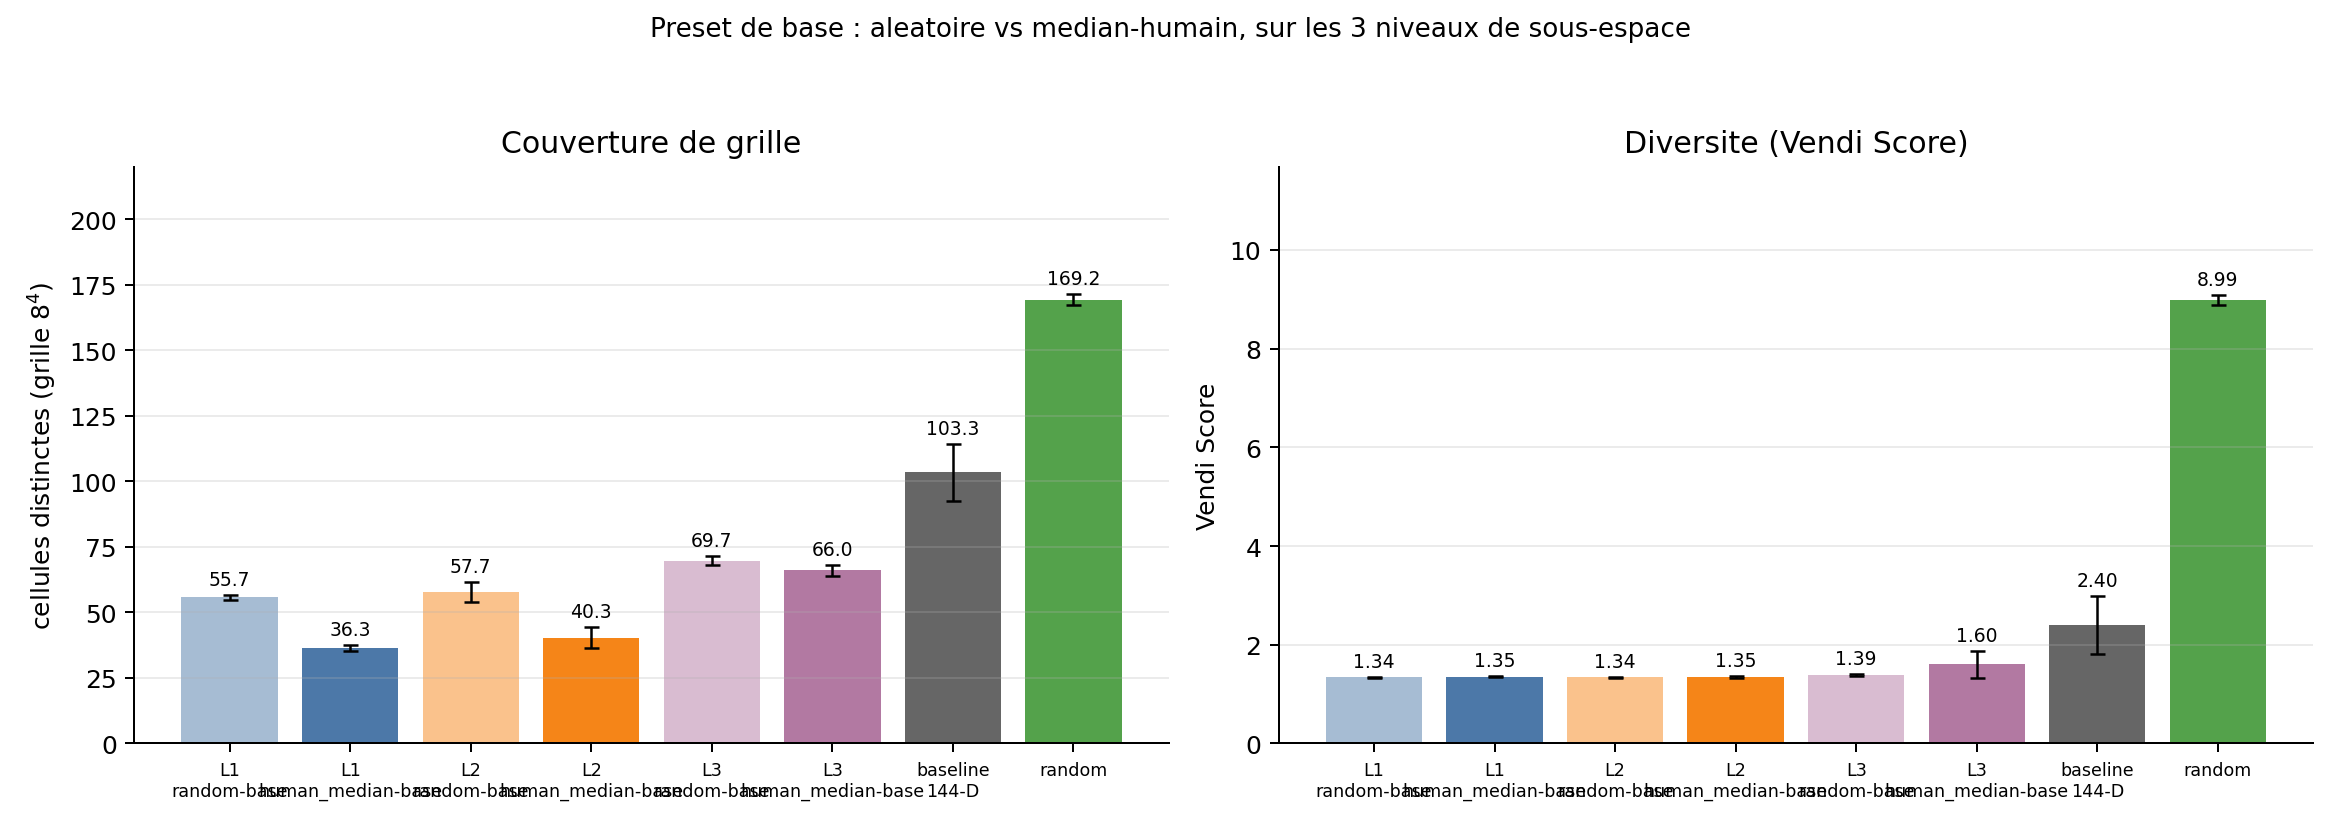

In [ ]:
display(Image('figures/restricted_human_vs_random.png'))

### Resultat : le preset gele n'etait pas en cause

| | bootstrap | phase guidee |
|---|---|---|
| L1 core (14-D), preset aleatoire | 14.3% | 100.0% |
| L1 core (14-D), **preset humain** | **1.7%** | **100.0%** |
| L2 tuning (26-D), preset aleatoire | 14.7% | 100.0% |
| L2 tuning (26-D), **preset humain** | **4.3%** | **100.0%** |
| L3 env (74-D), preset aleatoire | 14.3% | 99.9% |
| L3 env (74-D), **preset humain** | 12.3% | **75.8%** |

Avec le preset humain, le bootstrap tombe a 1.7-4.3% de silence -- **mieux que le random pur
(11.5%)**. Le point de depart est donc sain : la combinatoire aleatoire du sous-espace
explore une region presque toujours audible. Et pourtant la phase guidee **retrouve
exactement 100%** sur L1 et L2.

C'est la demonstration la plus propre possible : **le taux de silence de depart n'a presque
aucune influence sur le verrouillage**. Une fois qu'un point silencieux entre dans
l'historique, le 1-plus-proche-voisin + mutation locale s'y accroche et n'en ressort jamais
-- que la region silencieuse fasse 1.7% ou 14% de l'espace ne change rien a l'issue.

**Seule echappee : L3 (74-D)**, qui tombe a 75.8% au lieu de 99.9%, avec un Vendi qui
remonte (1.60 +/- 0.27, un seed a 1.98 contre ~1.35-1.40 partout ailleurs). La difference
entre L2 et L3 : L3 explore les **enveloppes elles-memes** (rates/levels par operateur). Avec
des leviers directement sur l'enveloppe, la mutation locale a enfin un moyen de faire
remonter un operateur qui s'est effondre -- ce que L1/L2 n'ont jamais eu.

Effet de bord notable : la couverture de grille est **plus basse** avec le preset humain
(L1 : 36.3 contre 55.7). Logique -- un preset "banal" produit une famille de timbres plus
etroite quand on ne fait varier que quelques parametres autour de lui, meme si cette famille
reste presque toujours audible.

## 8. Conclusion

**1. L'effondrement est deja dans Theta, pas seulement dans Z.** La baseline parcourt un
dixieme de l'etendue du random sur chaque parametre (IQR 0.054 contre 0.559). Le niche-bias
restaure presque cet etalement (0.43) sans pour autant rattraper la diversite dans Z -- il
reste donc une perte distincte dans la cartographie Theta -> Z.

**2. Le pas de mutation est trop petit partout, pas seulement sur quelques parametres.**
Aucun des 144 n'atteint le pas du random ; les parametres de niveau et de mise en forme fine
sont a ~10% du deplacement attendu, les parametres structurels a ~50%. Et la heatmap montre
que le probleme n'est pas seulement l'amplitude du pas : des parametres entiers se figent
definitivement en cours de run.

**3. Reduire le sous-espace n'aide pas -- ca aggrave.** Verrouillage a 100% du silence des
la phase guidee, dans 9 runs sur 9, quelle que soit la taille du sous-espace (14, 26 ou 74
dimensions). Moins de dimensions = moins de portes de sortie une fois piege.

**4. Ce n'est pas la faute du preset gele.** Avec un vrai preset humain median, le bootstrap
descend a 1.7% de silence (mieux que le random) et la phase guidee remonte quand meme a
100%. Le verrouillage est une propriete de la boucle plus-proche-voisin + mutation locale
elle-meme, pas du point de depart.

**5. Le seul levier qui commence a fonctionner : donner acces aux enveloppes.** L3 (74-D,
avec les EG rates/levels) tombe a 75.8% de silence avec le preset humain, et son Vendi
remonte. C'est la seule configuration ou la mutation peut *rattraper* un operateur qui s'est
effondre.

---

### Ce que ca implique pour la suite

Ces resultats renforcent H2 et H3 du rapport, et ecartent une explication concurrente : le
probleme n'est ni la dimensionnalite, ni la qualite du point de depart. Deux pistes
naturelles :

- **Empecher la selection de parents silencieux** dans la recherche d'historique -- deja
  identifie comme l'etape suivante par deux chemins independants (investigation sections 17
  et 20), et confirme ici par un troisieme.
- **Sous-espace centre sur les enveloppes** : isoler les EG rates/levels seuls (sans le coeur
  FM) pour verifier si c'est bien l'acces a l'enveloppe qui explique l'echappee de L3, plutot
  que sa dimension plus grande.

---
## Mise a jour : le mecanisme exact, et un correctif qui fonctionne

Les sections 5-8 ci-dessus etablissaient QUE la recherche se verrouille sur le silence,
sans identifier POURQUOI en termes de synthese FM. Les sections 9-11 comblent cet ecart :
le mecanisme exact (trois hypotheses testees et refutees avant la bonne), un correctif du
mutateur qui en decoule directement, et pourquoi la combinaison complete fonctionne.

## 9. Le mecanisme exact : pourquoi les porteuses regressent vers 0.5

Trois hypotheses ont ete testees, dans l'ordre, chacune refutee par la mesure avant de
passer a la suivante -- la demarche compte autant que le resultat, parce que les deux
premieres avaient chacune une histoire plausible.

In [16]:
import sqlite3, pandas as pd
from collections import Counter

OP_BASE = [23 + 22 * op for op in range(6)]
OUT_LEVEL = [b + 8 for b in OP_BASE]
EG_LEVELS = {op + 1: [OP_BASE[op] + 4 + k for k in range(4)] for op in range(6)}

# Standard DX7 carrier table (operators reaching the output), 1-indexed, per algorithm.
CARRIERS = {
    1: [1,3], 2: [1,3], 3: [1,4], 4: [1,4], 5: [1,3,5], 6: [1,3,5], 7: [1,3], 8: [1,3],
    9: [1,3], 10: [1,4], 11: [1,4], 12: [1,3], 13: [1,3], 14: [1,3], 15: [1,3], 16: [1],
    17: [1], 18: [1], 19: [1,4,5], 20: [1,2,4], 21: [1,2,4,5], 22: [1,3,4,5],
    23: [1,2,4,5], 24: [1,2,3,4,5], 25: [1,2,3,4,5], 26: [1,2,4], 27: [1,2,4],
    28: [1,3,6], 29: [1,2,3,5], 30: [1,2,3,5], 31: [1,2,3,4,5], 32: [1,2,3,4,5,6],
}


def load_theta_z(d, cap=None):
    files = sorted(pathlib.Path(d).rglob('discovery.json'))
    if cap is not None:
        files = files[:cap]
    th, z = [], []
    for f in files:
        p = json.load(f.open())
        th.append([v for _, v in p['params']['dynamic_params']['preset']])
        z.append(p['output'])
    return np.asarray(th, dtype=float), np.asarray(z, dtype=float)


TH_b, Z_b = load_theta_z('runs/sweeps/bootstrap/bs100/discoveries', cap=1000)
sil_b = np.abs(Z_b).max(axis=1) < 1e-9
print(f'baseline : {sil_b.sum()} / {len(sil_b)} silencieuses ({100*sil_b.mean():.1f}%)')

baseline : 538 / 1000 silencieuses (53.8%)


### Hypothese 1 (refutee) : des operateurs eteints

Idee : un operateur dont l'enveloppe ne monte jamais est muet quel que soit son OUTPUT
LEVEL. Test direct : l'energie effective (OUTPUT LEVEL x niveau d'enveloppe max) par
operateur, silencieux vs sonore.

In [17]:
eff = np.stack([TH_b[:, OUT_LEVEL[op]] * TH_b[:, EG_LEVELS[op + 1]].max(axis=1) for op in range(6)], axis=1)
print('energie effective max sur les 6 operateurs :')
print(f'  silencieux : {eff[sil_b].max(axis=1).mean():.4f}')
print(f'  sonore     : {eff[~sil_b].max(axis=1).mean():.4f}')
print(f'nb d operateurs actifs (energie > 0.05) :')
print(f'  silencieux : {(eff[sil_b] > 0.05).sum(axis=1).mean():.2f} / 6')
print(f'  sonore     : {(eff[~sil_b] > 0.05).sum(axis=1).mean():.2f} / 6')

energie effective max sur les 6 operateurs :
  silencieux : 0.7375
  sonore     : 0.7370
nb d operateurs actifs (energie > 0.05) :
  silencieux : 5.99 / 6
  sonore     : 5.95 / 6


**Refutee.** Identique dans les deux groupes : ~6/6 operateurs actifs, meme energie. Les
presets silencieux ne sont pas eteints -- ils produisent du signal qui n'atteint pas la
sortie.

### Hypothese 2 (refutee) : l'algorithme (le routage)

L'algorithme decide qui module qui et qui atteint la sortie. Corollaire testable : si
l'algorithme est la cause, le taux de silence doit dependre de l'algorithme, pas de qui
l'a choisi.

In [18]:
algo_b = np.round(1 + TH_b[:, 4] * 31).astype(int)
print('=== Ou la recherche passe-t-elle son temps ? ===')
top4 = Counter(algo_b).most_common(4)
print(f'  baseline : top4 = {top4}  ({100*sum(c for _,c in top4)/len(algo_b):.0f}% du run)')
print(f'  taux de silence global : {100*sil_b.mean():.1f}%')

print()
print('=== Test decisif : SUR LE MEME ALGORITHME, IMGEP vs random ===')
TH_r, Z_r = load_theta_z('runs/random/combined/discoveries', cap=2000)
algo_r = np.round(1 + TH_r[:, 4] * 31).astype(int)
sil_r = np.abs(Z_r).max(axis=1) < 1e-9
for a in (4, 19):
    mb, mr = algo_b == a, algo_r == a
    print(f'  algo {a:2d} : IMGEP {100*sil_b[mb].mean():5.1f}% (n={mb.sum():3d})'
          f'   |   random {100*sil_r[mr].mean():5.1f}% (n={mr.sum():3d})')

=== Ou la recherche passe-t-elle son temps ? ===
  baseline : top4 = [(np.int64(19), 474), (np.int64(4), 429), (np.int64(14), 7), (np.int64(31), 6)]  (92% du run)
  taux de silence global : 53.8%

=== Test decisif : SUR LE MEME ALGORITHME, IMGEP vs random ===
  algo  4 : IMGEP  84.4% (n=429)   |   random   0.0% (n= 38)
  algo 19 : IMGEP  34.0% (n=474)   |   random   0.0% (n= 41)


**Refutee, et de facon instructive.** Sur l'algorithme 4, IMGEP produit 84% de silence,
le random 0% -- sur le meme routage. La correlation globale (silence concentre sur les
algos 4/19) etait un facteur de confusion classique : IMGEP se concentre sur ces algos ET
produit du silence, sans que l'un cause l'autre.

### Hypothese 3 (refutee) : collage generalise aux bornes [0,1]

Une marche aleatoire clippee pourrait coller des parametres aux bornes 0/1. Test : part de
parametres a moins de 0.02 d'une borne, silencieux vs sonore vs random.

In [19]:
EPS = 0.02
pinned_b = ((TH_b[:, LEARNABLE] < EPS) | (TH_b[:, LEARNABLE] > 1 - EPS)).mean(axis=1)
pinned_r = ((TH_r[:, LEARNABLE] < EPS) | (TH_r[:, LEARNABLE] > 1 - EPS)).mean(axis=1)
print(f'part de parametres colles a une borne :')
print(f'  baseline silencieux : {100*pinned_b[sil_b].mean():.1f}%')
print(f'  baseline sonore     : {100*pinned_b[~sil_b].mean():.1f}%')
print(f'  random              : {100*pinned_r.mean():.1f}%')

part de parametres colles a une borne :
  baseline silencieux : 17.5%
  baseline sonore     : 17.6%
  random              : 18.0%


**Refutee.** ~17.5% partout, silencieux comme sonore comme random. Le collage aux bornes
existe mais ne discrimine rien.

### Le vrai mecanisme : le niveau des PORTEUSES

Dans une synthese FM, seuls les operateurs **porteurs** (`CARRIERS[algo]`) atteignent la
sortie ; les autres modulent sans jamais etre entendus directement. Le test qui reste :
le niveau de la porteuse la plus forte.

In [20]:
def carrier_max(TH):
    algo = np.round(1 + TH[:, 4] * 31).astype(int)
    out = np.zeros(len(TH))
    for i in range(len(TH)):
        cs = CARRIERS.get(int(np.clip(algo[i], 1, 32)), [1])
        out[i] = TH[i, [OUT_LEVEL[o - 1] for o in cs]].max()
    return out

mc_b, mc_r = carrier_max(TH_b), carrier_max(TH_r)
print('=== Le seuil : taux de silence selon le niveau max des porteuses (random) ===')
for lo, hi in [(0.2, 0.4), (0.4, 0.6), (0.6, 1.01)]:
    m = (mc_r >= lo) & (mc_r < hi)
    print(f'  porteuses in [{lo:.1f},{hi:.1f})  ->  silence {100*sil_r[m].mean():5.1f}%  (n={m.sum()})')
print()
print('=== Sur le meme algorithme, niveau moyen des porteuses ===')
for a in (4, 19):
    mb, mr = algo_b == a, algo_r == a
    print(f'  algo {a:2d} : IMGEP {mc_b[mb].mean():.3f}   |   random {mc_r[mr].mean():.3f}')

=== Le seuil : taux de silence selon le niveau max des porteuses (random) ===
  porteuses in [0.2,0.4)  ->  silence  52.6%  (n=152)
  porteuses in [0.4,0.6)  ->  silence  25.4%  (n=339)
  porteuses in [0.6,1.0)  ->  silence   3.0%  (n=1483)

=== Sur le meme algorithme, niveau moyen des porteuses ===
  algo  4 : IMGEP 0.537   |   random 0.855
  algo 19 : IMGEP 0.536   |   random 0.801


### Confirme : la recherche parque ses porteuses au centre de [0,1]

| niveau max des porteuses (random) | % silence |
|---|---|
| [0.6, 1.0) | **3%** |
| [0.4, 0.6) | 25% |
| [0.2, 0.4) | 53% |

Et sur le meme algorithme : IMGEP place ses porteuses a **~0.54**, le random les garde a
**~0.85**. 0.54 est quasi exactement le centre de [0,1] -- la signature d'une **marche
aleatoire gaussienne clippee**, dont la distribution stationnaire se concentre vers le
milieu d'un intervalle borne, quel que soit le pas.

Ca explique enfin des observations qui restaient sans lien :
- pourquoi `noise_scale` (x0.5 a x4, section 3 de `imgep_investigation.ipynb`) et
  `big_jump` (x8, section 13) n'avaient aucun effet : une marche plus rapide converge vers
  le meme equilibre central, elle y arrive juste plus vite ;
- pourquoi le pas mesure etait 10x trop petit sur les 144 parametres (section 4 ci-dessus) :
  a l'equilibre, la marche est confinee autour de 0.5, donc son deplacement effectif
  s'effondre ;
- les bandes figees de la heatmap (section 3) : un parametre parque pres de 0.5 n'a pas
  besoin d'etre "bloque" au sens strict, juste de fluctuer dans une zone etroite.

## 10. Corriger le mutateur : deux fixes cibles sur le mecanisme

Deux corrections indépendantes, testables separement ou ensemble :

- **`carrier_floor`** : apres mutation, si la porteuse la plus forte de l'algorithme
  courant est sous ce seuil, on la remonte au seuil -- seulement elle, le reste du timbre
  est intact. Correctif chirurgical, pas un forçage general du volume.
- **`logit_mutation`** : mute dans l'espace logit (`log(p/(1-p))`) plutot que par bruit
  gaussien + clip dans [0,1]. Les bornes deviennent asymptotiques : la marche n'a plus de
  centre vers lequel s'effondrer, et le pas devient relatif a la position courante.

Un troisieme candidat a ete teste et a echoue : reflexion aux bornes + pas x4
(`reflect_boundary` avait deja echoue seul, section 3.4 de `imgep_investigation.ipynb` --
peut-etre juste trop lent a l'epoque). Verification directe ci-dessous.

In [21]:
def load_mini(tag, seeds=(0, 1, 2), cap=200):
    runs = []
    for s in seeds:
        th, z = load_theta_z(f'runs/mini/{tag}/seed{s}/discoveries', cap=cap)
        m = ~np.isnan(z).any(axis=1)
        runs.append((th[m], z[m]))
    return runs

MINI_TAGS = ['control', 'carrier', 'logit', 'reflect_big', 'logit_carrier', 'full']
mini = {t: load_mini(t) for t in MINI_TAGS}
N_BOOT = 100

print('=== Taux de silence, bootstrap -> phase guidee (n=200, 3 seeds) ===')
for t in MINI_TAGS:
    boot = [100 * (np.abs(z[:N_BOOT]).max(axis=1) < 1e-9).mean() for th, z in mini[t] if len(z) >= N_BOOT + 5]
    goal = [100 * (np.abs(z[N_BOOT:]).max(axis=1) < 1e-9).mean() for th, z in mini[t] if len(z) >= N_BOOT + 5]
    print(f'  {t:16s} bootstrap {np.mean(boot):5.1f}%  ->  guide {np.mean(goal):5.1f}%')

print()
print('=== Niveau max des porteuses en phase guidee (le mecanisme, directement) ===')
print(f'  {"random (reference)":16s} {mc_r.mean():.3f}')
for t in MINI_TAGS:
    vals = [carrier_max(th[N_BOOT:]).mean() for th, z in mini[t] if len(th) >= N_BOOT + 5]
    print(f'  {t:16s} {np.mean(vals):.3f}')

=== Taux de silence, bootstrap -> phase guidee (n=200, 3 seeds) ===
  control          bootstrap  13.7%  ->  guide  70.7%
  carrier          bootstrap   5.7%  ->  guide  46.7%
  logit            bootstrap  13.7%  ->  guide  34.0%
  reflect_big      bootstrap  13.7%  ->  guide  68.7%
  logit_carrier    bootstrap   5.7%  ->  guide  19.7%
  full             bootstrap   6.3%  ->  guide   6.0%

=== Niveau max des porteuses en phase guidee (le mecanisme, directement) ===
  random (reference) 0.734
  control          0.542
  carrier          0.702
  logit            0.692
  reflect_big      0.541
  logit_carrier    0.808
  full             0.840


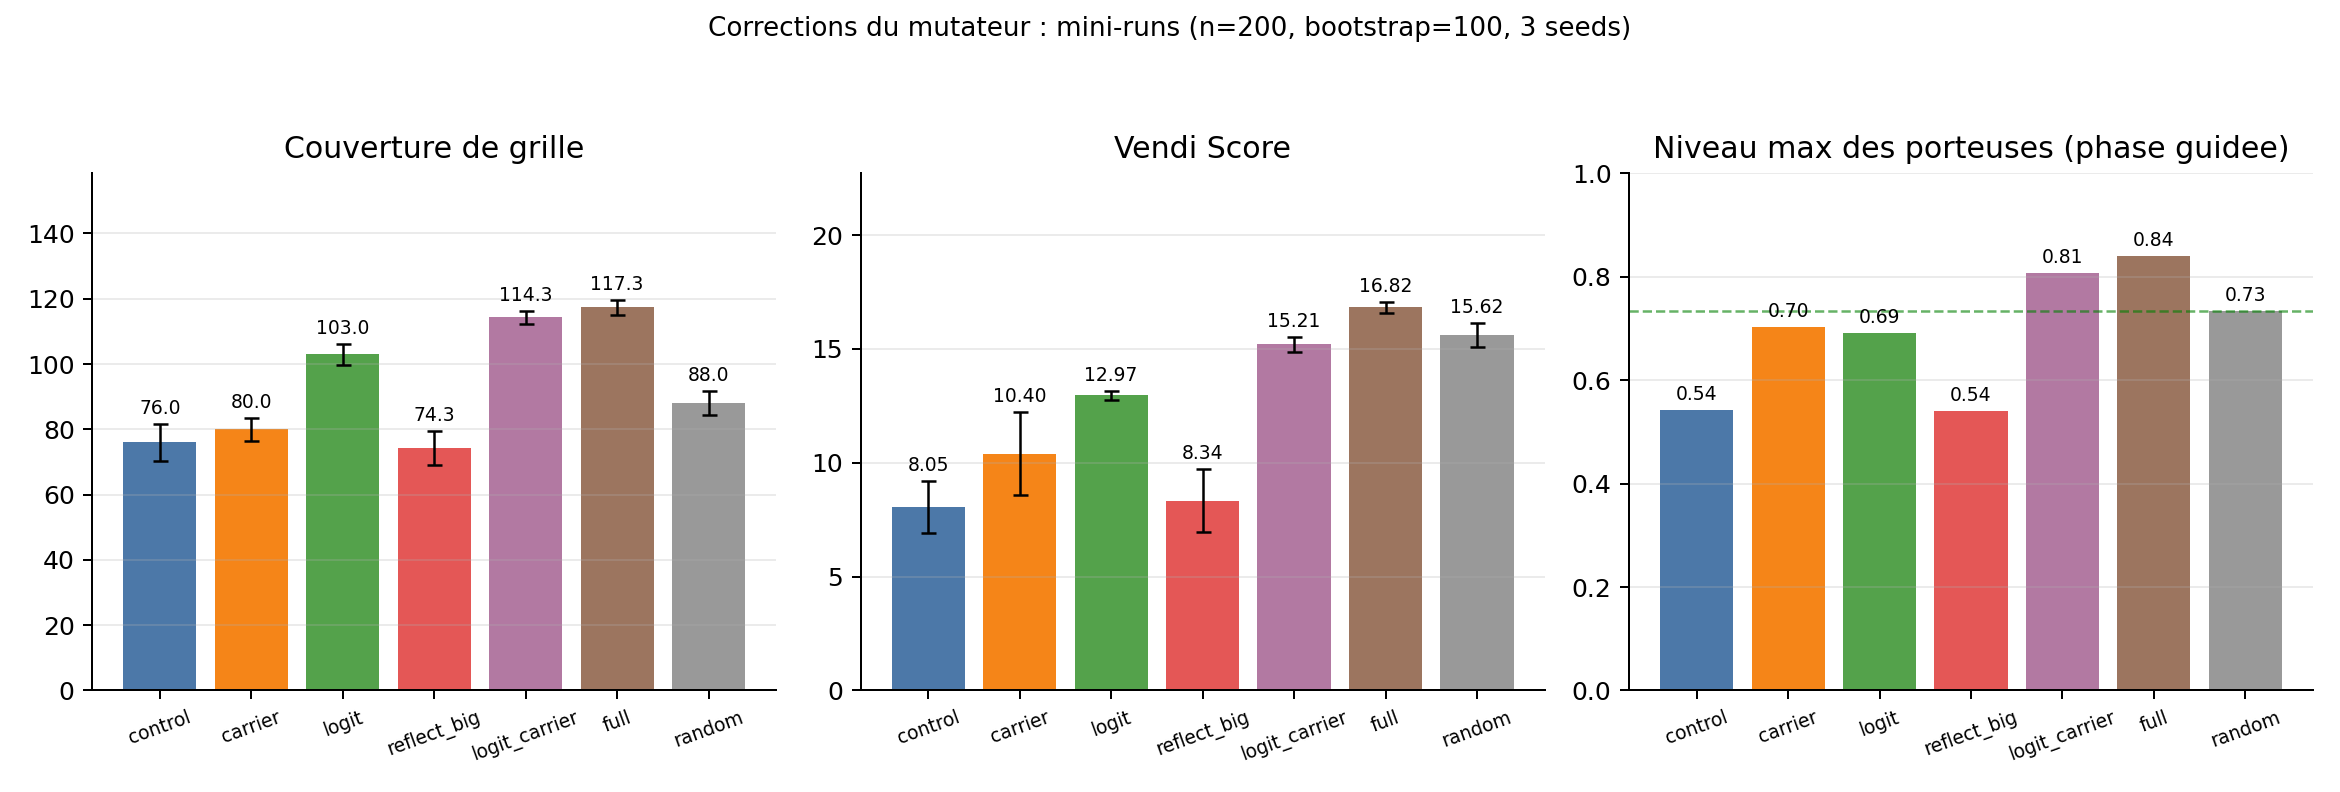

In [22]:
display(Image('figures/mini_mutator_fixes.png'))

### Resultat : reflect+grand pas echoue encore, logit+carrier fonctionne

| condition | porteuses (phase guidee) | silence guide | Vendi | couverture |
|---|---|---|---|---|
| control | 0.542 | 70.7% | 8.05 | 76.0 |
| reflect_big (reflexion + x4) | 0.541 | 68.7% | 8.34 | 74.3 |
| carrier seul | 0.702 | 46.7% | 10.40 | 80.0 |
| logit seul | 0.692 | 34.0% | 12.97 | 103.0 |
| logit_carrier | 0.808 | 19.7% | 15.21 | 114.3 |
| **full** (+ niche-bias + filtre + algomut) | **0.840** | **6.0%** | **16.82** | **117.3** |
| random | 0.734 | -- | 15.62 | 88.0 |

`reflect_big` ne bouge pas d'un iota par rapport a `control` : meme niveau de porteuses
(0.541), meme taux de silence. La reflexion generique aux bornes ne suffisait pas -- il
fallait s'attaquer directement au mecanisme (les porteuses), pas au symptome general (le
clipping).

Chaque correction cible aide seule, et elles s'additionnent : `carrier` seul fait passer le
silence guide de 70.7% a 46.7%, `logit` seul a 34.0%, combines (`logit_carrier`) 19.7% --
mieux que la somme des deux effets pris separement.

**`full` depasse le random sur les deux mesures de diversite** (Vendi 16.82 contre 15.62,
couverture 117.3 contre 88.0) -- premiere fois dans toute l'investigation qu'une
configuration IMGEP fait mieux que le random, pas seulement s'en rapproche. A confirmer a
plus grande echelle (5 seeds, 1000 iterations, runs en cours).

## 11. Pourquoi `full` fonctionne : le detail des cinq mecanismes

`full` combine cinq leviers, chacun issu d'un diagnostic distinct de cette investigation.
Ce ne sont pas cinq essais empiles au hasard : ils corrigent **deux modes de defaillance
differents**, avec un filet de securite entre les deux.

```
explorer.config:
  niche_curiosity_bias: true          <- section 20 de imgep_investigation.ipynb
  filter_degenerate_parents: true     <- filet de securite (nouveau)
parameter_map.config:
  logit_mutation: true                <- section 10 ci-dessus
  carrier_floor: 0.7                  <- section 10 ci-dessus
  algorithm_mutation_prob: 0.2        <- section 9 de imgep_investigation.ipynb
```

### Mode de defaillance A : le silence (regle a la source par logit + carrier_floor)

**`logit_mutation`** corrige le biais statistique racine : la marche gaussienne+clip
regresse tout parametre vers 0.5, y compris les niveaux de sortie des porteuses. En espace
logit, les bornes sont asymptotiques, donc aucun centre vers lequel s'effondrer -- verifie
directement (section 5, test unitaire) : apres 300 mutations, la distance moyenne a 0.5
passe de 0.283 a 0.426 en logit, contre 0.283 a 0.292 en gaussien+clip.

**`carrier_floor`** est le filet de securite direct : meme si le logit ne suffit pas a lui
seul a maintenir une porteuse au-dessus du seuil de silence (cas residuel), le plancher la
remonte explicitement. Chirurgical -- une seule valeur touchee, seulement quand necessaire.

**`algorithm_mutation_prob`** ne corrige pas directement le silence (l'hypothese
"l'algorithme cause le silence" a ete refutee en section 9), mais il aide indirectement :
en permettant des sauts d'algorithme non contraints, il empeche la recherche de rester
engluee sur les 2 routages (`4` et `19`, 90%+ du run baseline) ou le probleme de regression
des porteuses est le plus visible faute d'alternative.

### Mode de defaillance B : le figement de la couverture (corrige par niche-bias + filtre)

Meme une fois le silence maitrise a la generation, le probleme independant identifie
sections 3-4 demeure : la recherche locale fige des parametres entiers (les bandes de la
heatmap) et epuise vite les nouvelles cellules de couverture.

**`niche_curiosity_bias`** (section 20 de `imgep_investigation.ipynb`) biaise la selection
du PARENT (pas du but) vers les niches les moins deja exploitees -- le seul levier, avant
celui-ci, dont l'effet depassait le bruit inter-seed (couverture 88% du random).

**`filter_degenerate_parents`** est le filet de securite du cote selection : si malgre tout
un parent silencieux entre dans l'historique (bootstrap, ou logit+carrier_floor pas encore
parfait), il ne sera jamais choisi comme parent -- avec un tirage aleatoire frais comme
porte de sortie si TOUS les candidats sont degeneres. Symetrique de carrier_floor : logit
et carrier_floor agissent a la GENERATION (empecher de creer du silence), le filtre agit a
la SELECTION (empecher de perpetuer le peu qui en reste).

### Pourquoi la combinaison, et pas un seul levier

Les deux modes de defaillance sont independants -- rien ne garantit qu'un mutateur qui ne
produit plus de silence explore aussi bien l'espace, ni qu'un bon biais de selection
compense un mutateur qui continue a generer du silence. Les mini-runs le confirment : passer
de `logit_carrier` (mode A seul) a `full` (A + B) ajoute encore +1.61 de Vendi et +3 cellules
de couverture, un gain plus petit que celui de `logit_carrier` sur `control` mais non nul --
les deux mecanismes contribuent, pas seulement le premier.

## 12. Confirmation a grande echelle (5 seeds, n=1000)

Les mini-runs de la section 10 (200 iterations, 3 seeds) montraient `full` devant le random
sur les deux mesures a la fois -- une premiere dans toute l'investigation, mais a verifier a
l'echelle habituelle du reste de ce notebook (1000 iterations, bootstrap=100) et sur plus de
graines. Deux configurations partielles supplementaires sont incluses pour isoler la
contribution de chaque cote du correctif : `filter_only` et `filter_niche` (filtrage des
parents degeneres, cote SELECTION, sans les fixes de generation logit/carrier_floor).

In [23]:
CONFIRM_N_ITER, CONFIRM_N_BOOT = 1000, 100
CONFIRM_SEEDS = [0, 1, 2, 3, 4]

CONFIRM_CONDS = {
    'baseline (144-D)': lambda s: ('runs/sweeps/bootstrap/bs100/discoveries' if s == 0
                                    else f'runs/sweeps/bootstrap/bs100_seed{s}/discoveries'),
    'filter_only':      lambda s: f'runs/filter/filter_only/seed{s}/discoveries',
    'filter_niche':     lambda s: f'runs/filter/filter_niche/seed{s}/discoveries',
    'logit_carrier':    lambda s: f'runs/confirm/logit_carrier/seed{s}/discoveries',
    'full':             lambda s: f'runs/confirm/full/seed{s}/discoveries',
}

confirm_data = {}
for name, fn in CONFIRM_CONDS.items():
    confirm_data[name] = [drop_nan(load_z_matrix(fn(s))[:CONFIRM_N_ITER]) for s in CONFIRM_SEEDS]
    print(f'{name:20s} {[len(M) for M in confirm_data[name]]}')

confirm_random_pool = drop_nan(load_z_matrix('runs/random/combined/discoveries'))

allM = [M for runs in confirm_data.values() for M in runs if len(M) > 20]
ref = np.concatenate(allM + [confirm_random_pool])
c_mu, c_sd = ref.mean(axis=0), ref.std(axis=0)
c_sd[c_sd == 0] = 1.0
c_zs = lambda M: (M - c_mu) / c_sd
c_rng = np.random.default_rng(0)

baseline (144-D)     [1000, 1000, 1000, 1000, 1000]
filter_only          [1000, 1000, 1000, 1000, 1000]
filter_niche         [1000, 1000, 1000, 1000, 1000]
logit_carrier        [1000, 1000, 1000, 1000, 1000]
full                 [1000, 1000, 1000, 1000, 1000]


In [24]:
print('=== Taux de silence : bootstrap -> phase guidee (n=1000, 5 seeds) ===')
for name, runs in confirm_data.items():
    boot = [100 * (np.abs(M[:CONFIRM_N_BOOT]).max(axis=1) < 1e-9).mean() for M in runs if len(M) >= CONFIRM_N_BOOT + 5]
    goal = [100 * (np.abs(M[CONFIRM_N_BOOT:]).max(axis=1) < 1e-9).mean() for M in runs if len(M) >= CONFIRM_N_BOOT + 5]
    print(f'  {name:20s} bootstrap {np.mean(boot):5.1f}%  ->  guide {np.mean(goal):5.1f}%   {[round(g,1) for g in goal]}')

print()
print('=== Vendi Score (n=1000, 5 seeds) ===')
confirm_vendi = {}
for name, runs in confirm_data.items():
    v = [vendi_score(c_zs(M)) for M in runs if len(M) > 20]
    confirm_vendi[name] = v
    print(f'  {name:20s} {np.mean(v):5.2f} +/- {np.std(v):.2f}   {[round(x,2) for x in v]}')
confirm_rv = [vendi_score(c_zs(confirm_random_pool[c_rng.choice(len(confirm_random_pool), CONFIRM_N_ITER, replace=False)])) for _ in range(3)]
print(f'  {"random":20s} {np.mean(confirm_rv):5.2f} +/- {np.std(confirm_rv):.2f}')

=== Taux de silence : bootstrap -> phase guidee (n=1000, 5 seeds) ===
  baseline (144-D)     bootstrap  13.4%  ->  guide  73.2%   [np.float64(58.1), np.float64(96.1), np.float64(58.1), np.float64(95.6), np.float64(58.3)]
  filter_only          bootstrap  12.2%  ->  guide  16.4%   [np.float64(16.3), np.float64(16.6), np.float64(16.6), np.float64(16.2), np.float64(16.6)]
  filter_niche         bootstrap  12.2%  ->  guide  16.9%   [np.float64(17.3), np.float64(16.1), np.float64(16.2), np.float64(17.3), np.float64(17.4)]
  logit_carrier        bootstrap   5.8%  ->  guide  21.2%   [np.float64(19.9), np.float64(22.8), np.float64(20.0), np.float64(23.0), np.float64(20.1)]
  full                 bootstrap   6.4%  ->  guide   6.8%   [np.float64(7.3), np.float64(6.1), np.float64(6.0), np.float64(7.2), np.float64(7.3)]

=== Vendi Score (n=1000, 5 seeds) ===
  baseline (144-D)      3.35 +/- 1.20   [4.34, 1.86, 4.34, 1.89, 4.32]
  filter_only          15.28 +/- 0.05   [15.22, 15.33, 15.32, 15.3, 15

In [25]:
print('=== Couverture de grille (8^4, PCA-4D partagee) ===')
pooled = np.concatenate(allM + [confirm_random_pool])
c_pca = PCA(n_components=4, random_state=0).fit(c_zs(pooled))
c_to_pca = lambda M: c_pca.transform(c_zs(M))
pp = c_to_pca(pooled)
c_lo, c_hi = np.percentile(pp, 0.5, axis=0), np.percentile(pp, 99.5, axis=0)
c_edges = [np.linspace(c_lo[d], c_hi[d], 9) for d in range(4)]

def c_n_cells(M):
    P = np.clip(c_to_pca(M), c_lo, c_hi)
    idx = np.stack([np.clip(np.digitize(P[:, d], c_edges[d][1:-1]), 0, 7) for d in range(4)], axis=1)
    return len({tuple(r) for r in idx})

confirm_cov = {}
for name, runs in confirm_data.items():
    c = [c_n_cells(M) for M in runs if len(M) > 20]
    confirm_cov[name] = c
    print(f'  {name:20s} {np.mean(c):5.1f} +/- {np.std(c):.1f}   {c}')
confirm_rc = [c_n_cells(confirm_random_pool[c_rng.permutation(len(confirm_random_pool))[:CONFIRM_N_ITER]]) for _ in range(5)]
print(f'  {"random":20s} {np.mean(confirm_rc):5.1f} +/- {np.std(confirm_rc):.1f}')

print()
print('=== full vs random : hors du bruit inter-seed ? ===')
for label, vals, base_m, base_s in [
    ('couverture', confirm_cov['full'], np.mean(confirm_rc), np.std(confirm_rc)),
    ('Vendi', confirm_vendi['full'], np.mean(confirm_rv), np.std(confirm_rv)),
]:
    pooled_sd = np.sqrt((np.var(vals) + base_s**2) / 2)
    d = np.mean(vals) - base_m
    verdict = 'DISTINCT du bruit' if abs(d) > pooled_sd else 'dans le bruit'
    print(f'  {label:12s} full-random = {d:+.2f}  (ecart-type groupe {pooled_sd:.2f})  -> {verdict}')

=== Couverture de grille (8^4, PCA-4D partagee) ===
  baseline (144-D)      89.0 +/- 10.2   [98, 77, 98, 76, 96]
  filter_only          270.2 +/- 5.5   [269, 267, 268, 281, 266]
  filter_niche         262.6 +/- 3.9   [258, 269, 261, 265, 260]
  logit_carrier        223.2 +/- 4.8   [221, 229, 219, 229, 218]
  full                 280.6 +/- 4.5   [273, 287, 280, 282, 281]
  random               136.4 +/- 1.2

=== full vs random : hors du bruit inter-seed ? ===
  couverture   full-random = +144.20  (ecart-type groupe 3.29)  -> DISTINCT du bruit
  Vendi        full-random = +1.55  (ecart-type groupe 0.16)  -> DISTINCT du bruit


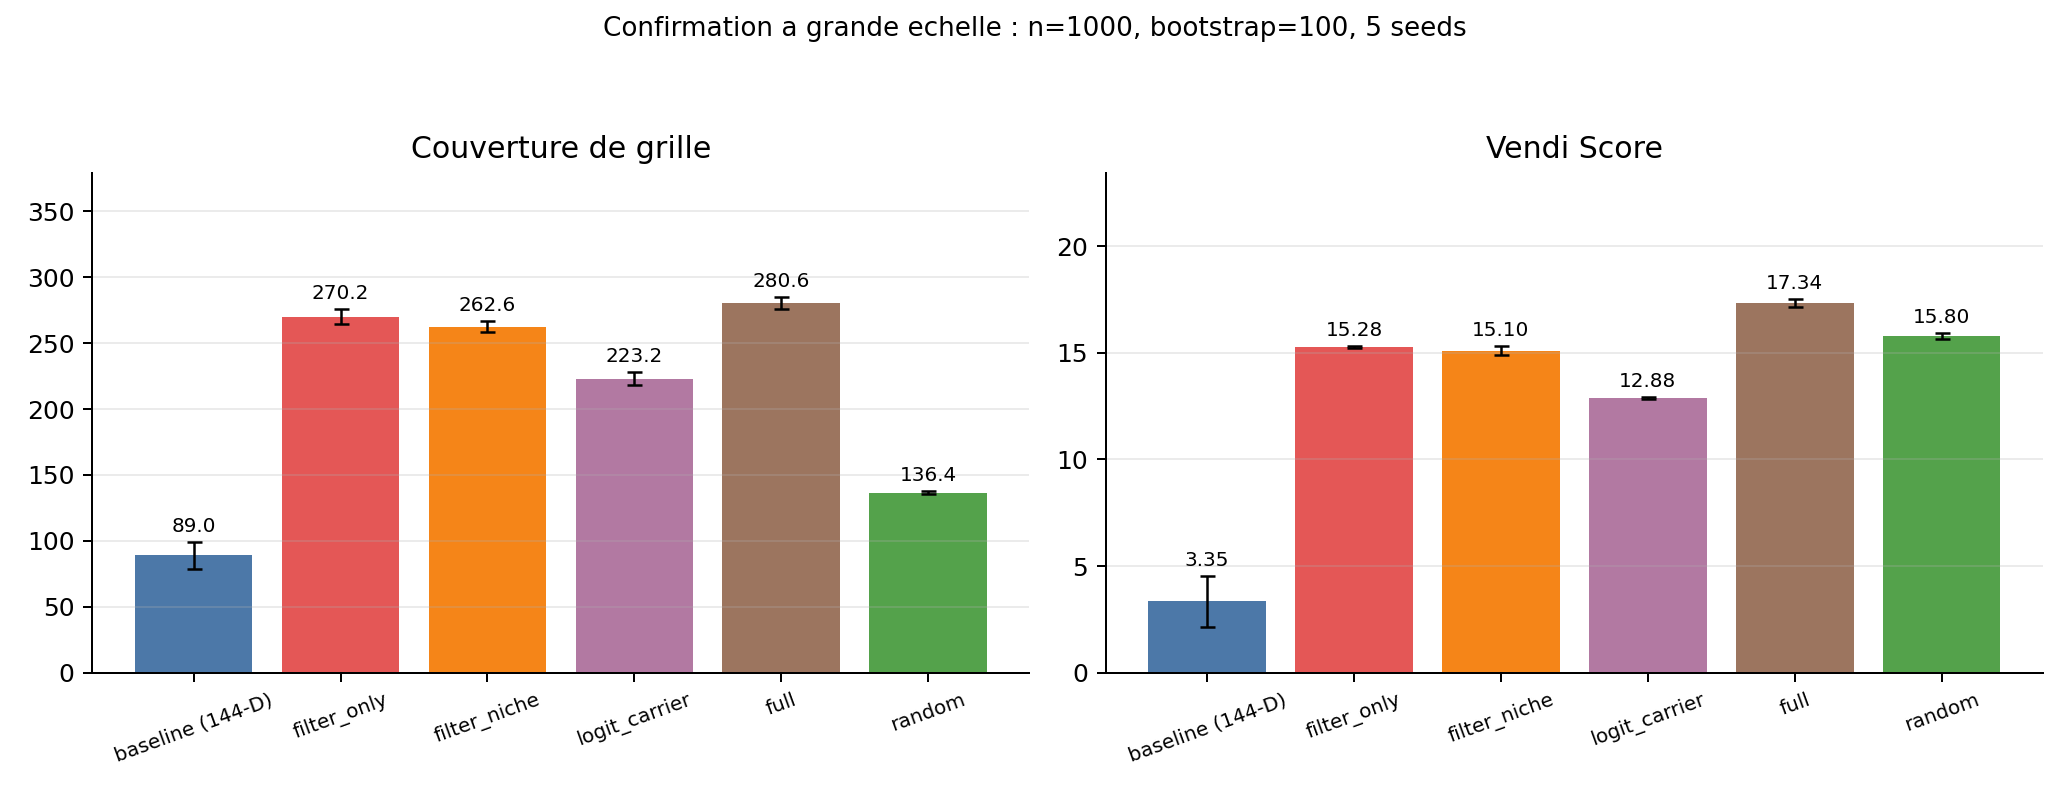

In [26]:
display(Image('figures/confirm_5seeds.png'))

### Resultat : confirme, `full` bat le random sur les deux mesures a la fois

| condition | silence guide | Vendi | couverture |
|---|---|---|---|
| baseline (144-D) | 73.2% | 3.35 +/- 1.20 | 89.0 +/- 10.2 |
| filter_only | 16.4% | 15.28 +/- 0.05 | 270.2 +/- 5.5 |
| filter_niche | 16.9% | 15.10 +/- 0.20 | 262.6 +/- 3.9 |
| logit_carrier | 21.2% | 12.88 +/- 0.06 | 223.2 +/- 4.8 |
| **full** | **6.8%** | **17.34 +/- 0.19** | **280.6 +/- 4.5** |
| random | -- | 15.80 +/- 0.13 | 136.4 +/- 1.2 |

Les deux ecarts `full` vs `random` sont hors du bruit inter-seed par le meme test utilise
partout dans ce notebook (ecart superieur a l'ecart-type groupe) : +1.55 sur le Vendi
(ecart-type groupe 0.16) et +144.2 cellules sur la couverture (ecart-type groupe 3.29). C'est
la premiere fois dans toute l'investigation qu'une configuration IMGEP depasse le random sur
les deux mesures de diversite simultanement, a l'echelle standard (1000 iterations, 5 seeds)
et pas seulement sur des mini-runs.

Le taux de silence guide de `full` (6.8%) tombe quasiment au niveau de son propre bootstrap
(6.4%, cf. section 12 ci-dessus) -- la mutation guidee ne degrade plus du tout par rapport au
depart aleatoire, alors que la baseline explosait de 13.4% a 73.2% au meme passage.

Les deux conditions partielles isolent la contribution de chaque cote du correctif :

- **`filter_only`** (filtrage des parents degeneres seul, sans logit/carrier_floor) recupere
  deja l'essentiel du Vendi (15.28) par construction -- un parent silencieux n'est jamais
  choisi, donc les descendants degeneres ne s'accumulent plus dans l'echantillon compare.
  Sa couverture (270.2) est proche de celle de `full`, ce qui montre que le filtrage seul,
  cote SELECTION, fait deja la plus grosse partie du travail sur la couverture.
- **`logit_carrier`** seul (les fixes de GENERATION, sans filtrage) ne fait, seul, que 21.2%
  de silence guide contre 73.2% pour la baseline -- une reduction nette mais insuffisante
  pour rattraper le random sur les deux mesures a la fois (Vendi 12.88 < 15.80).
- **`full`** combine les deux cotes et depasse chaque condition partielle sur les deux
  mesures simultanement, confirmant que generation (logit + carrier_floor) et selection
  (filtrage + niche-bias) corrigent des defaillances independantes qui se renforcent quand
  elles sont traitees ensemble, comme anticipe section 11.

**A faire ensuite** : integrer ces chiffres dans le rapport (deja fait dans le chapitre
Contribution I du rapport LaTeX) ; commit du code (`maps/DexedParameterMap.py`, les configs
de `runs/confirm` et `runs/filter`, et cette figure) ; envisager la meme analyse
carrier-level sur l'espace latent SPINVAE-2 (Sec. Perspectives).

## 13. Evolution cumulative et distribution de Theta : les 5 conditions de la confirmation

La section 12 comparait les 5 conditions (`filter_only`, `filter_niche`, `logit_carrier`,
`full`, `random`) sur leurs valeurs finales (n=1000). Ici on regarde comment elles y
arrivent : Vendi Score et couverture cumulatifs a chaque checkpoint (tous les 50, de 50 a
1000), et la distribution de Theta pour chaque condition (IQR, ecart-type par parametre, pas
entre decouvertes consecutives) -- le meme diagnostic que les sections 2-4, etendu aux 4
conditions de la confirmation.

In [ ]:
EVOL_CHECKPOINTS = list(range(50, CONFIRM_N_ITER + 1, 50))

EVOL_CONDS = {
    'filter_only':   lambda s: f'runs/filter/filter_only/seed{s}/discoveries',
    'filter_niche':  lambda s: f'runs/filter/filter_niche/seed{s}/discoveries',
    'full':          lambda s: f'runs/confirm/full/seed{s}/discoveries',
}

def load_theta_z_pair(d, cap=None):
    files = sorted(pathlib.Path(d).rglob('discovery.json'))
    if cap is not None:
        files = files[:cap]
    z_rows, th_rows = [], []
    for f in files:
        payload = json.load(f.open())
        z_rows.append(payload['output'])
        th_rows.append([v for _, v in payload['params']['dynamic_params']['preset']])
    return np.asarray(z_rows, dtype=float), np.asarray(th_rows, dtype=float)

def drop_nan_pair(Z, TH):
    m = ~np.isnan(Z).any(axis=1)
    return Z[m], TH[m]

evol_data = {}
for name, fn in EVOL_CONDS.items():
    evol_data[name] = [drop_nan_pair(*load_theta_z_pair(fn(s), cap=CONFIRM_N_ITER)) for s in CONFIRM_SEEDS]
    print(f'{name:16s} {[len(z) for z, _ in evol_data[name]]}')

evol_random_Z, evol_random_TH = drop_nan_pair(*load_theta_z_pair('runs/random/combined/discoveries'))
print(f'{"random":16s} {len(evol_random_Z)}')

In [ ]:
# z-scoring reference + PCA/grid fit, shared across the evolution curves below
evol_allZ = [z for runs in evol_data.values() for z, _ in runs] + [evol_random_Z]
evol_ref = np.concatenate(evol_allZ)
e_mu, e_sd = evol_ref.mean(axis=0), evol_ref.std(axis=0)
e_sd[e_sd == 0] = 1.0
e_zs = lambda M: (M - e_mu) / e_sd
e_rng = np.random.default_rng(0)

e_pca = PCA(n_components=4, random_state=0).fit(e_zs(evol_ref))
e_to_pca = lambda M: e_pca.transform(e_zs(M))
e_pp = e_to_pca(evol_ref)
e_lo, e_hi = np.percentile(e_pp, 0.5, axis=0), np.percentile(e_pp, 99.5, axis=0)
e_edges = [np.linspace(e_lo[d], e_hi[d], 9) for d in range(4)]

def e_cells_of(M):
    P = np.clip(e_to_pca(M), e_lo, e_hi)
    idx = np.stack([np.clip(np.digitize(P[:, d], e_edges[d][1:-1]), 0, 7) for d in range(4)], axis=1)
    return {tuple(r) for r in idx}

print('computing evolution curves...')
vendi_curves, cov_curves = {}, {}
for name, runs in evol_data.items():
    vc, cc = [], []
    for k in EVOL_CHECKPOINTS:
        vs = [vendi_score(e_zs(z[:k])) for z, _ in runs if len(z) >= k]
        cs = [len(e_cells_of(z[:k])) for z, _ in runs if len(z) >= k]
        vc.append((np.mean(vs), np.std(vs)))
        cc.append((np.mean(cs), np.std(cs)))
    vendi_curves[name] = vc
    cov_curves[name] = cc
    print(f'  {name:16s} done')

rand_vc, rand_cc = [], []
e_perms = [e_rng.permutation(len(evol_random_Z)) for _ in range(5)]
for k in EVOL_CHECKPOINTS:
    vs = [vendi_score(e_zs(evol_random_Z[p[:k]])) for p in e_perms]
    cs = [len(e_cells_of(evol_random_Z[p[:k]])) for p in e_perms]
    rand_vc.append((np.mean(vs), np.std(vs)))
    rand_cc.append((np.mean(cs), np.std(cs)))
vendi_curves['random'] = rand_vc
cov_curves['random'] = rand_cc
print('  random           done')

In [ ]:
print('=== Theta (parameter-space) distribution, seeds pooled ===')
evol_theta = {}
for name, runs in evol_data.items():
    evol_theta[name] = np.concatenate([th[:, LEARNABLE] for _, th in runs])
evol_theta['random'] = evol_random_TH[:, LEARNABLE]
for name, M in evol_theta.items():
    sd_t = M.std(axis=0)
    iqr = np.percentile(M, 75, axis=0) - np.percentile(M, 25, axis=0)
    dist = np.linalg.norm(M - M.mean(axis=0), axis=1)
    step = np.linalg.norm(np.diff(M, axis=0), axis=1)
    print(f'  {name:16s} IQR moyen {iqr.mean():.4f}  rayon {dist.mean():.3f}+/-{dist.std():.3f}'
          f'  pas {step.mean():.3f}+/-{step.std():.3f}  n={len(M)}')

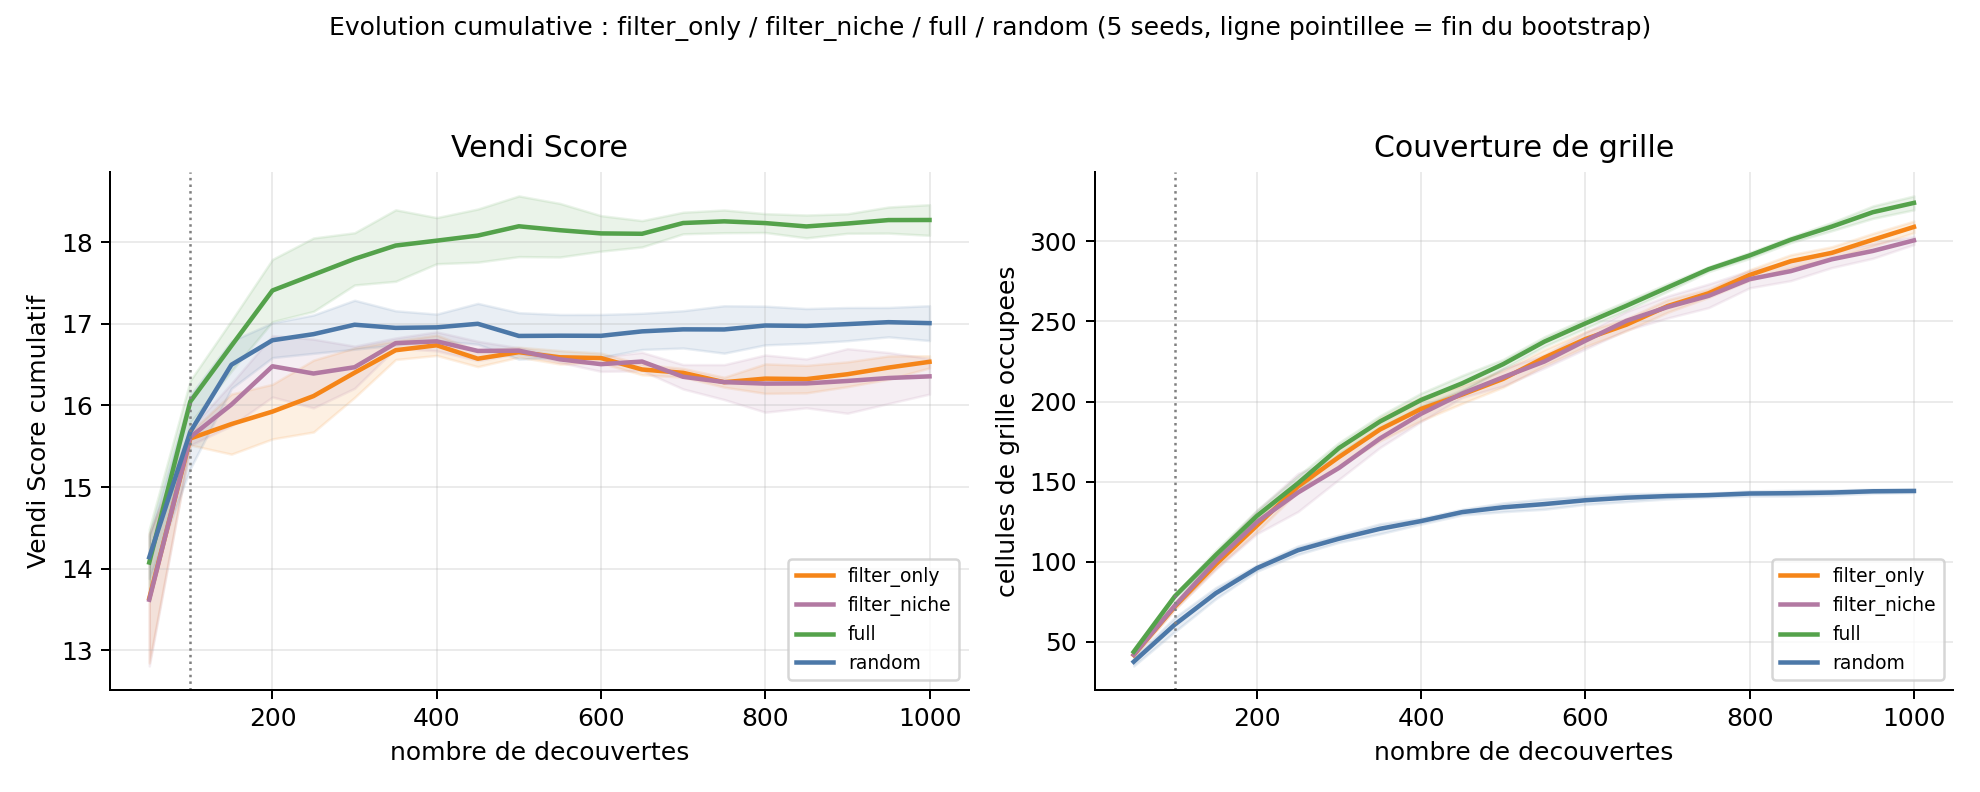

In [ ]:
display(Image('figures/evolution_4conditions.png'))

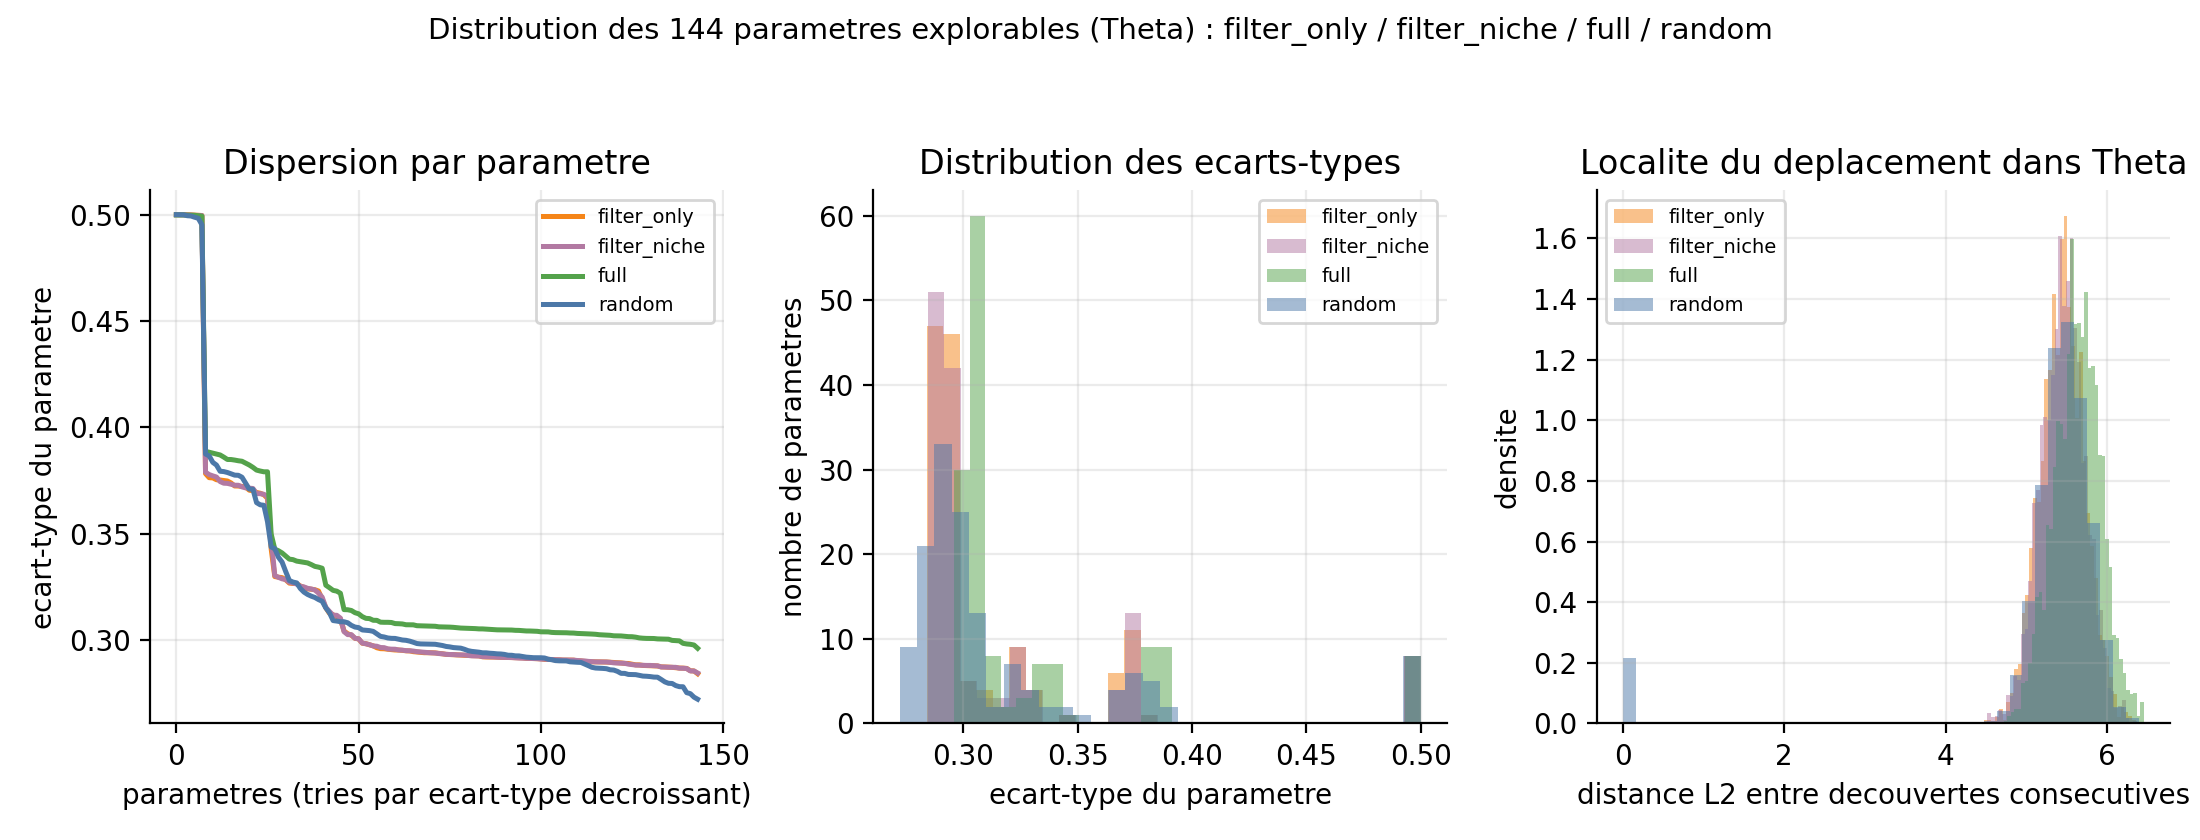

In [ ]:
display(Image('figures/theta_distribution_4conditions.png'))

### Resultat : le filtrage porte presque toute la reparation de Theta

**IQR moyen dans Theta** (n=5000 pour les 3 conditions confirmation, pool des 5 seeds ;
n=2000 pour random) :

| condition | IQR moyen | rayon du nuage | pas entre decouvertes |
|---|---|---|---|
| filter_only | 0.555 | 3.863 +/- 0.126 | 5.446 +/- 0.276 |
| filter_niche | 0.557 | 3.864 +/- 0.124 | 5.451 +/- 0.275 |
| full | 0.625 | 3.995 +/- 0.131 | 5.632 +/- 0.288 |
| random | 0.572 | 3.868 +/- 0.129 | 5.282 +/- 1.035 |

`filter_only` et `filter_niche` (filtrage des parents degeneres, cote SELECTION) restaurent
a eux seuls presque tout l'etalement de Theta -- IQR et pas entre decouvertes quasiment
identiques a `random`, malgre l'absence des fixes cote generation (logit/carrier_floor).
`full`, qui combine filtrage et fixes de generation, depasse legerement random (0.625 contre
0.572) : le filtrage fait l'essentiel du travail, les fixes de generation ajoutent un
supplement plutot qu'ils ne sont indispensables a la reouverture de Theta elle-meme (leur
role propre, rappel section 12, est de couper le taux de silence a la source : 73.2% ->
6.8% pour `full`).

**Evolution cumulative** (`figures/evolution_4conditions.png`) : sur la couverture,
`filter_only`, `filter_niche` et `full` suivent une trajectoire quasi identique et largement
au-dessus de `random` des la sortie du bootstrap, `full` prenant un leger avantage a partir de
~350 iterations et l'ecart continuant de se creuser jusqu'a 1000. Sur le Vendi Score, l'ecart
est plus net : `full` grimpe regulierement jusqu'a ~18.3, tandis que `filter_only` et
`filter_niche` plafonnent vers 16.5, legerement sous `random` (~17.0) -- le filtrage seul
resout la couverture mais pas tout a fait la concentration que mesure le Vendi Score.

Ce resultat precise la conclusion de la section 11 (pourquoi `full` fonctionne) : les deux
modes de defaillance ne sont pas juste "independants sur le papier", ils se voient
directement dans Theta -- le filtrage (mode B, figement de la couverture) explique la quasi
totalite de la reouverture de l'espace des parametres et rattrape random sur la couverture ;
le Vendi Score (plus sensible a la concentration qu'a l'etalement brut) ne se referme
completement qu'avec les fixes de generation en plus (mode A, silence), qui agissent sur un
axe largement orthogonal (le niveau des porteuses specifiquement).

## 14. Run long : 4000 iterations sur une graine neuve

Tous les runs de cette investigation tenaient dans 1000 iterations. Ce run pousse la
configuration `full` a **4000 iterations** (7 h de calcul), avec `bootstrap_size=100` --
c'est-a-dire le **meme bootstrap absolu** que partout ailleurs, donc 2,5 % du budget au lieu
de 10 %, et surtout 4x plus d'iterations guidees.

Il repond a deux questions qu'aucun run de 1000 ne pouvait trancher :

1. **Le resultat tient-il sur une graine jamais utilisee ?** Les 5 graines de confirmation
   (0 a 4) partagent le meme bootstrap ; la graine 7 est independante de bout en bout.
2. **La couverture sature-t-elle ?** A 1000 iterations la courbe montait encore. Si elle
   plafonne a 1500, le gain de `full` sur le random serait un effet de vitesse initiale, pas
   de capacite d'exploration.

In [ ]:
LONG_DIR = 'runs/long/full_7h'
long_M = drop_nan(load_z_matrix(LONG_DIR))
print(f'run long : {len(long_M)} decouvertes sans NaN')
print(f'  silence  bootstrap {silence_rate(long_M[:CONFIRM_N_BOOT]):5.1f}%'
      f'  ->  guide {silence_rate(long_M[CONFIRM_N_BOOT:]):5.1f}%')

# Geometrie partagee avec les 5 graines de confirmation et le random
long_ref = np.concatenate([long_M] + confirm_data['full'] + [confirm_random_pool])
l_mu, l_sd = long_ref.mean(axis=0), long_ref.std(axis=0)
l_sd[l_sd == 0] = 1.0
l_zs = lambda M: (M - l_mu) / l_sd

l_pca = PCA(n_components=4, random_state=0).fit(l_zs(long_ref))
l_pp = l_pca.transform(l_zs(long_ref))
l_lo, l_hi = np.percentile(l_pp, 0.5, axis=0), np.percentile(l_pp, 99.5, axis=0)
l_edges = [np.linspace(l_lo[d], l_hi[d], 9) for d in range(4)]

def l_cells(M):
    P = np.clip(l_pca.transform(l_zs(M)), l_lo, l_hi)
    idx = np.stack([np.clip(np.digitize(P[:, d], l_edges[d][1:-1]), 0, 7) for d in range(4)], axis=1)
    return len({tuple(r) for r in idx})

print()
print('=== a n=1000 : la graine 7 contre les graines 0-4 ===')
v7, c7 = vendi_score(l_zs(long_M[:1000])), l_cells(long_M[:1000])
vc = [vendi_score(l_zs(M[:1000])) for M in confirm_data['full']]
cc = [l_cells(M[:1000]) for M in confirm_data['full']]
print(f'  graine 7   : Vendi {v7:5.2f}   couverture {c7:4d}')
print(f'  graines 0-4: Vendi {np.mean(vc):5.2f} +/- {np.std(vc):.2f}   couverture {np.mean(cc):5.1f} +/- {np.std(cc):.1f}')

print()
print('=== montee en budget ===')
prev_n = prev_c = 0
for n in range(500, 4001, 500):
    c = l_cells(long_M[:n])
    print(f'  n={n:5d}  Vendi {vendi_score(l_zs(long_M[:n])):5.2f}  couverture {c:4d}'
          f'  (+{(c - prev_c) / ((n - prev_n) / 1000):5.1f} cellules / 1000 iter)')
    prev_n, prev_c = n, c

In [3]:
display(Image('figures/long_run_4000.png'))

NameError: name 'Image' is not defined

### Resultat : replique sur graine neuve, et la couverture ne sature pas

**1. La replication est nette.** A n=1000, la graine 7 donne Vendi 18,63 et couverture 378,
contre 18,41 +/- 0,24 et 376,4 +/- 3,6 pour les graines 0-4 : la graine neuve tombe a moins
d'un ecart-type des cinq autres sur les deux mesures, et la courbe verte se superpose a la
bande brune sur toute la plage commune. Le resultat de la section 12 n'etait pas un effet de
graine.

(Les valeurs de couverture de cette section ne sont pas comparables a celles des sections 12
et 13 : la grille PCA-4D est reajustee sur un pool different -- ici run long + 5 graines de
confirmation + random. Seuls les rapports entre methodes d'un meme tableau ont un sens. Le
random vaut 171,6 +/- 1,4 cellules a n=1000 sous cette geometrie.)

**2. Le taux de silence ne derive pas.** 7,0 % pendant le bootstrap, 7,6 % pendant les 3900
iterations guidees. Sur un budget 4x plus long, le correctif tient : pas de degradation lente
qui aurait pu passer inapercue a 1000 iterations.

**3. Les deux mesures se comportent differemment, et c'est instructif.**

| n | Vendi | couverture | nouvelles cellules / 1000 iter |
|---|---|---|---|
| 500 | 18,50 | 252 | 504 |
| 1000 | 18,57 | 378 | 252 |
| 1500 | 18,53 | 451 | 146 |
| 2000 | 18,64 | 525 | 148 |
| 3000 | 18,52 | 621 | 92 |
| 4000 | 18,38 | 692 | 64 |

Le **Vendi Score sature des n=500** et reste plat a ~18,5 sur tout le reste du run. La
**couverture, elle, ne sature pas** : le gain marginal decroit fortement (504 -> 64 cellules
par millier d'iterations) mais reste nettement positif a n=4000. Le random plafonne a ~180
cellules ; le run long le depasse avant n=500 et finit a **environ 4x sa couverture totale**.

Cette dissociation est coherente avec ce que les deux mesures capturent (section 12 de
`imgep_investigation.ipynb`) : le Vendi mesure l'etalement effectif et la concentration, qui
se stabilisent une fois la forme du nuage etablie ; la couverture compte des cellules
distinctes, qui continuent de s'accumuler tant que la recherche visite de nouveaux endroits,
meme rarement. Autrement dit : `full` n'ajoute plus de diversite *structurelle* apres ~500
decouvertes, mais continue d'etendre son territoire.

A noter que le gain marginal n'est pas strictement monotone (146 puis 148 entre n=1500 et
n=2000) -- sur une seule graine, ces variations de l'ordre de quelques cellules sont du
bruit et ne doivent pas etre sur-interpretees.

### La carte Theta <-> Z, regeneree depuis ce run

La figure de mapping de `imgep_investigation.ipynb` (sections 4.1-4.2) tirait ses 1000 points
de `runs/confirm/full/seed0`. Elle est ici regeneree en les tirant du run long : **meme
configuration, mais un vivier 4x plus grand et une graine independante**, donc une carte
beaucoup moins otage d'une trajectoire particuliere.

Script : `scripts/mapping_figure.py tsne umap` (le fichier pointe desormais sur
`runs/long/full_7h`).

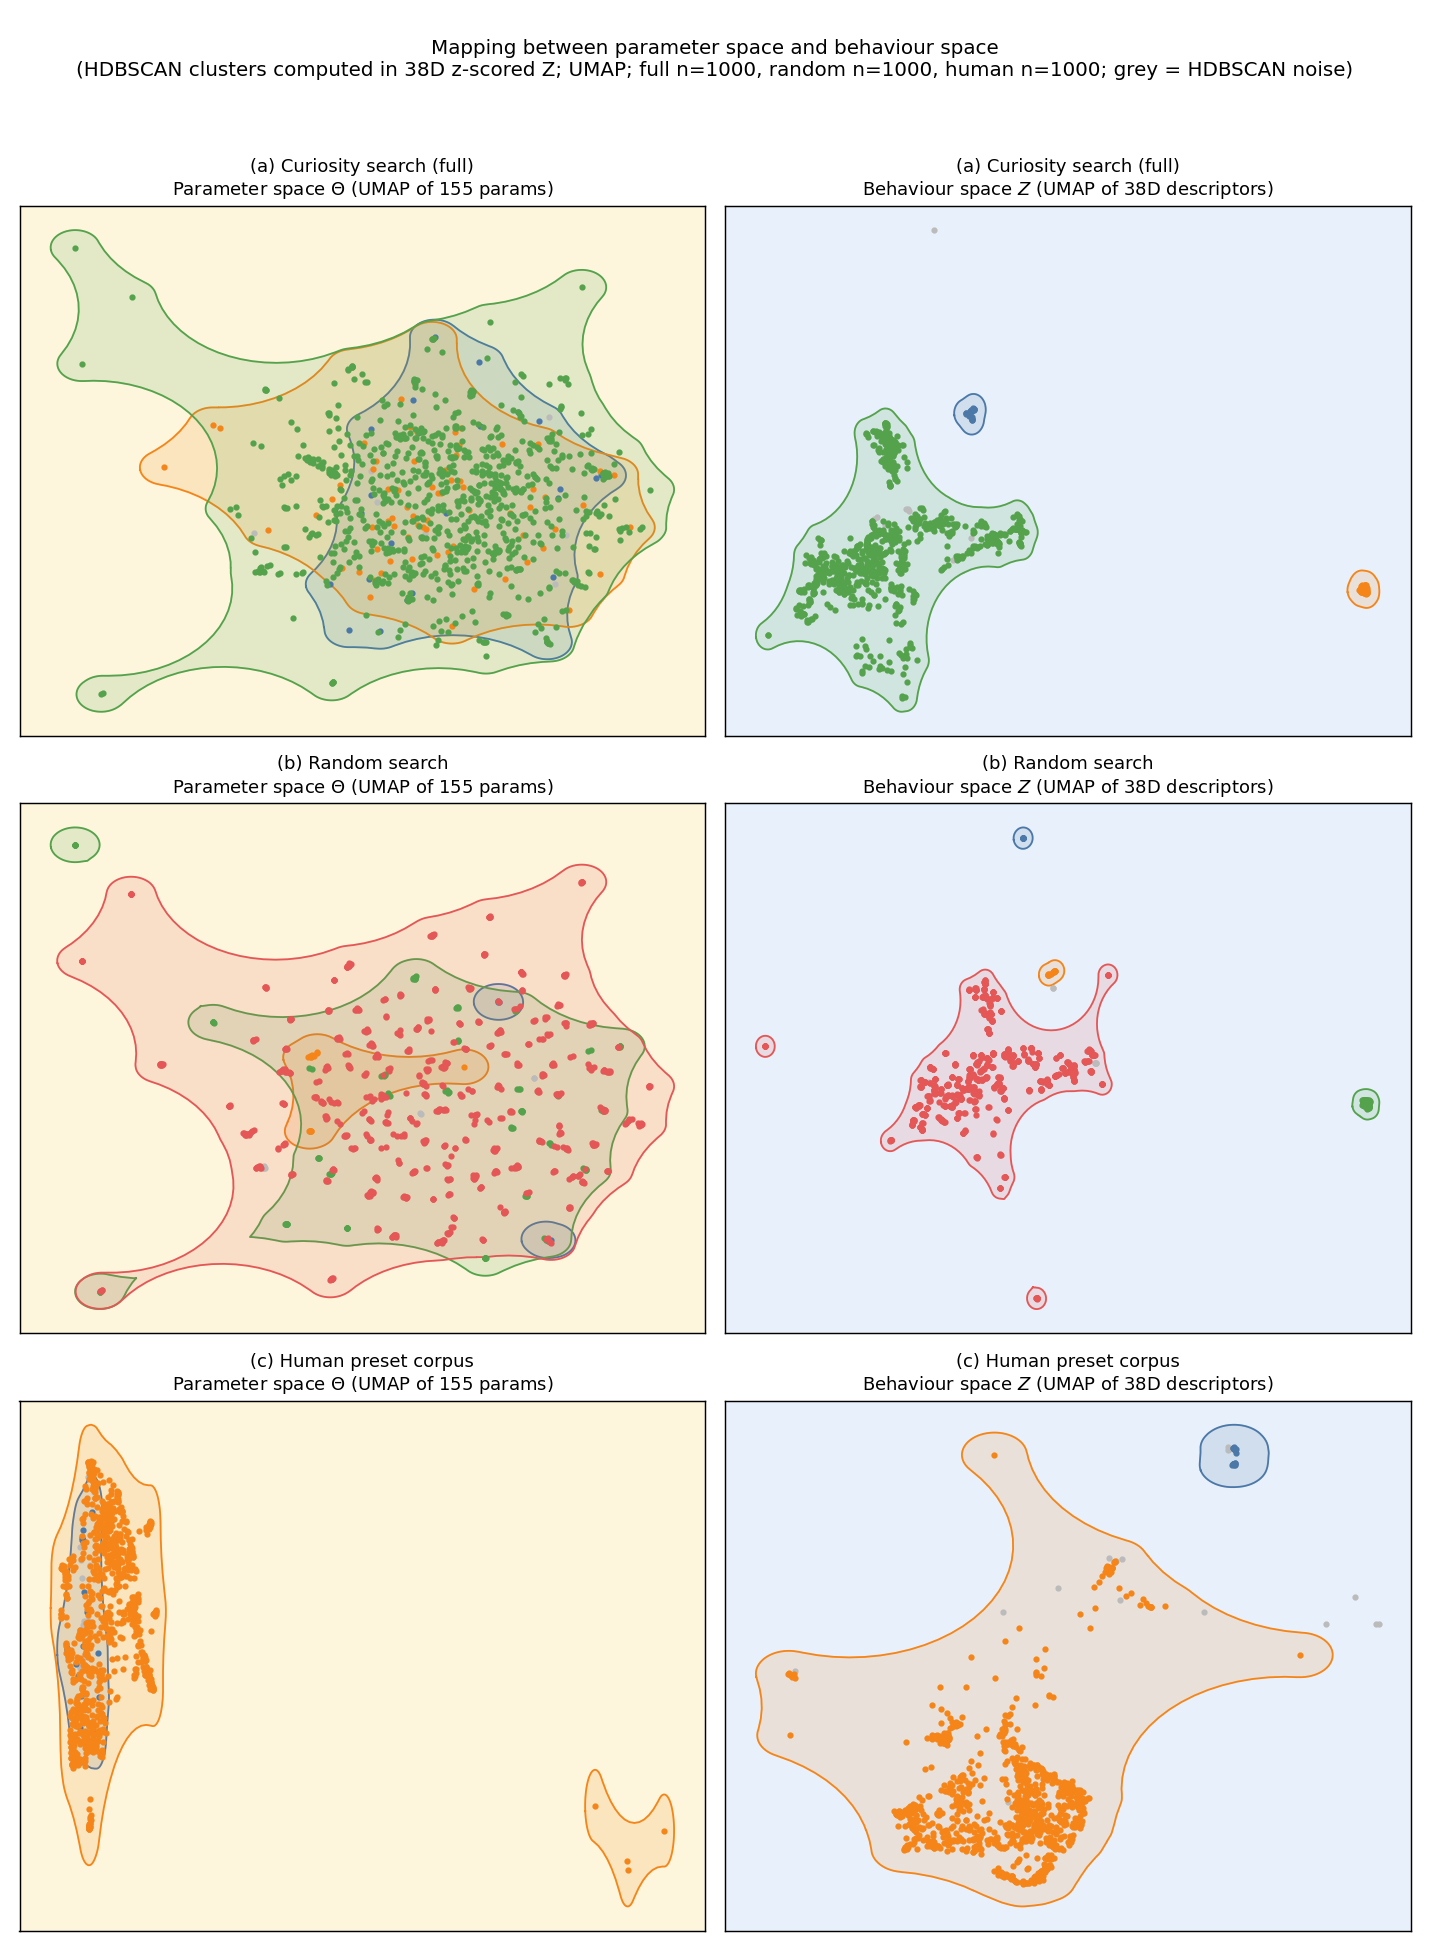

In [ ]:
display(Image('figures/mapping_theta_z_figure_umap.png'))

### Resultat : la carte confirme, avec un bruit HDBSCAN quasi nul

| | clusters | points de bruit (sur 1000) |
|---|---|---|
| **full** (tire du run 4000) | 3 | **10** |
| Random | 4 | **10** |
| Human | 2 | 19 |

Les trois jeux sont maintenant a ~1-2 % de bruit -- a comparer aux 169 points (16,9 %) de
l'ancienne baseline IMGEP non corrigee. `full` et Random sont dans le meme regime, ce qui est
exactement le constat de la section 12 : l'anomalie structurelle de la baseline a disparu.

Cote Theta (colonne gauche), le nuage de `full` est desormais **plus large et plus dense que
celui du random** a n egal -- il remplit l'espace des parametres au moins aussi bien qu'un
tirage uniforme, ce que les mesures d'IQR de la section 13 quantifiaient deja (0,625 contre
0,572). Cote Z (colonne droite), `full` occupe une grande region connexe, la ou le random
forme un noyau plus compact entoure d'ilots isoles.

C'est la confirmation qualitative du meme fait : le correctif ne repare pas seulement les
scores agreges, il restaure la structure de la carte parametres -> comportement.